# ATTAG driver gene prediction and analysis

This notebook adapts the adjacent Python script into editable, documented sections. Run the final cell to train the configured model, generate predictions, and display the plots inline. The training cell can take a while; edit the configuration cell before running if you want a different network, model, threshold, or epoch count.

The original script defines several historical variants of similarly named functions. This notebook keeps the final definition of each repeated class or function name, which is the definition Python uses after loading the script.


## 1. Imports and notebook plotting setup

Load the same libraries used by the script. Matplotlib figures created by the pipeline will render in notebook output.

In [1]:
%matplotlib inline
import argparse
import json
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from dgl import function as fn
from dgl.nn import SAGEConv, GATConv, GraphConv
from torch.utils.data import DataLoader
import os
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from collections import defaultdict
import scipy.stats
from scipy.stats import spearmanr
import pandas as pd
from dgl.nn.pytorch import GINConv
from dgl.nn.pytorch import ChebConv
from dgl.nn.pytorch import TAGConv
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from torch_geometric.utils import dropout_edge, negative_sampling, remove_self_loops, add_self_loops
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
from torch.nn.functional import sigmoid
from sklearn.cluster import SpectralBiclustering
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn.pytorch import TAGConv


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dlopen(/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_sparse/_convert_cpu.so, 0x0006): Symbol not found: __ZN2at8internal15invoke_parallelExxxRKNSt3__18functionIFvxxEEE
  Referenced from: <B7A49972-B945-390D-952D-B14A1F34B4B7> /Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_sparse/_convert_cpu.so
  Expected in:     <F30C371B-792B-396A-93AB-5B28EF7BFD21> /Users/ericsali/miniforge3/envs/kg39/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


## 2. GNN architectures and model selection

Define the graph model classes and the `choose_model` factory used by the prediction pipeline.

In [2]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ##bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        # Ensure targets are of type float
        targets = targets.float()

        # Compute BCE loss
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

        probas = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probas, 1 - probas)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()
class HGDC(torch.nn.Module):
    def __init__(self, args, weights=[0.95, 0.90, 0.15, 0.10]):
        super().__init__()
        self.args = args
        in_channels = self.args.in_channels
        hidden_channels = self.args.hidden_channels
        self.linear1 = Linear(in_channels, hidden_channels)

        # 3 convolutional layers for the original network
        self.conv_k1_1 = GCNConv(hidden_channels, hidden_channels, add_self_loops=False)
        self.conv_k2_1 = GCNConv(2 * hidden_channels, hidden_channels, add_self_loops=False)
        self.conv_k3_1 = GCNConv(2 * hidden_channels, hidden_channels, add_self_loops=False)
        
        # 3 convolutional layers for the auxiliary network
        self.conv_k1_2 = GCNConv(hidden_channels, hidden_channels, add_self_loops=False)
        self.conv_k2_2 = GCNConv(2 * hidden_channels, hidden_channels, add_self_loops=False)
        self.conv_k3_2 = GCNConv(2 * hidden_channels, hidden_channels, add_self_loops=False)

        self.linear_r0 = Linear(hidden_channels, 1)
        self.linear_r1 = Linear(2 * hidden_channels, 1)
        self.linear_r2 = Linear(2 * hidden_channels, 1)
        self.linear_r3 = Linear(2 * hidden_channels, 1)

        # Attention weights on outputs of different convolutional layers
        self.weight_r0 = torch.nn.Parameter(torch.Tensor([weights[0]]), requires_grad=True)
        self.weight_r1 = torch.nn.Parameter(torch.Tensor([weights[1]]), requires_grad=True)
        self.weight_r2 = torch.nn.Parameter(torch.Tensor([weights[2]]), requires_grad=True)
        self.weight_r3 = torch.nn.Parameter(torch.Tensor([weights[3]]), requires_grad=True)

    def forward(self, data):
        x_input = data.x
        edge_index_1 = data.edge_index
        edge_index_2 = data.edge_index_aux

        edge_index_1, _ = dropout_edge(edge_index_1, p=0.5, 
                                       force_undirected=True, 
                                       training=self.training)
        edge_index_2, _ = dropout_edge(edge_index_2, p=0.5, 
                                       force_undirected=True, 
                                       training=self.training)

        x_input = F.dropout(x_input, p=0.5, training=self.training)

        R0 = torch.relu(self.linear1(x_input))

        R_k1_1 = self.conv_k1_1(R0, edge_index_1)
        R_k1_2 = self.conv_k1_2(R0, edge_index_2)
        R1 = torch.cat((R_k1_1, R_k1_2), 1)

        R_k2_1 = self.conv_k2_1(R1, edge_index_1)
        R_k2_2 = self.conv_k2_2(R1, edge_index_2)
        R2 = torch.cat((R_k2_1, R_k2_2), 1)

        R_k3_1 = self.conv_k3_1(R2, edge_index_1)
        R_k3_2 = self.conv_k3_2(R2, edge_index_2)
        R3 = torch.cat((R_k3_1, R_k3_2), 1)

        R0 = F.dropout(R0, p=0.5, training=self.training)
        res0 = self.linear_r0(R0)
        R1 = F.dropout(R1, p=0.5, training=self.training)
        res1 = self.linear_r1(R1)
        R2 = F.dropout(R2, p=0.5, training=self.training)
        res2 = self.linear_r2(R2)
        R3 = F.dropout(R3, p=0.5, training=self.training)
        res3 = self.linear_r3(R3)

        out = res0 * self.weight_r0 + res1 * self.weight_r1 + res2 * self.weight_r2 + res3 * self.weight_r3
        return out
class MTGCN(torch.nn.Module):
    def __init__(self, args):
        super(MTGCN, self).__init__()
        self.args = args
        self.conv1 = ChebConv(58, 300, K=2, normalization="sym")
        self.conv2 = ChebConv(300, 100, K=2, normalization="sym")
        self.conv3 = ChebConv(100, 1, K=2, normalization="sym")

        self.lin1 = Linear(58, 100)
        self.lin2 = Linear(58, 100)

        self.c1 = torch.nn.Parameter(torch.Tensor([0.5]))
        self.c2 = torch.nn.Parameter(torch.Tensor([0.5]))

    def forward(self, data):
        edge_index, _ = dropout_edge(data.edge_index, p=0.5,
                                     force_undirected=True,
                                     num_nodes=data.x.size()[0],
                                     training=self.training)
        E = data.edge_index
        pb, _ = remove_self_loops(data.edge_index)
        pb, _ = add_self_loops(pb)

        x0 = F.dropout(data.x, training=self.training)
        x = torch.relu(self.conv1(x0, edge_index))
        x = F.dropout(x, training=self.training)
        x1 = torch.relu(self.conv2(x, edge_index))

        x = x1 + torch.relu(self.lin1(x0))
        z = x1 + torch.relu(self.lin2(x0))

        pos_loss = -torch.log(torch.sigmoid((z[E[0]] * z[E[1]]).sum(dim=1)) + 1e-15).mean()

        neg_edge_index = negative_sampling(pb, data.num_nodes, data.num_edges)

        neg_loss = -torch.log(
            1 - torch.sigmoid((z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=1)) + 1e-15).mean()

        r_loss = pos_loss + neg_loss

        x = F.dropout(x, training=self.training)
        x = self.conv3(x, edge_index)

        return x, r_loss, self.c1, self.c2
class EMOGI(torch.nn.Module):
    def __init__(self,args):
        super(EMOGI, self).__init__()
        self.args = args
        self.conv1 = ChebConv(58, 300, K=2)
        self.conv2 = ChebConv(300, 100, K=2)
        self.conv3 = ChebConv(100, 1, K=2)

    def forward(self, data):
        edge_index = data.edge_index
        x = F.dropout(data.x, training=self.training)
        x = torch.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = torch.relu(self.conv2(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv3(x, edge_index)

        return x
class ATTAG_residual(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Topology Adaptive Graph Convolution Network (ATTAG).
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops in TAGConv.
        """
        super(ATTAG, self).__init__()
        self.tag1 = TAGConv(in_feats, hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for ATTAG with residual connections.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through TAGConv layers with residual connection.
        """
        # First TAGConv layer with residual connection
        residual1 = features
        x = F.relu(self.tag1(g, features), inplace=False)  # Ensure no inplace modification
        x = x + residual1  # Use x + residual1 instead of inplace addition

        # Second TAGConv layer with residual connection
        residual2 = x
        x = F.relu(self.tag2(g, x), inplace=False)  # Ensure no inplace modification
        x = x + residual2  # Use x + residual2 instead of inplace addition

        return self.mlp(x)
class ATTAG_drop_k2(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=2, dropout=0.5):
        """
        Topology Adaptive Graph Convolution Network (ATTAG) with residual connections and dropout.
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops in TAGConv.
        - dropout: Dropout probability (default: 0.5).
        """
        super(ATTAG, self).__init__()
        self.tag1 = TAGConv(in_feats, hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        self.dropout = nn.Dropout(p=dropout)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for ATTAG with residual connections and dropout.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through TAGConv layers with residual connections and dropout.
        """
        # First TAGConv layer with residual connection
        residual1 = features
        x = F.relu(self.tag1(g, features), inplace=False)
        x = self.dropout(x)
        x = x + residual1

        # Second TAGConv layer with residual connection
        residual2 = x
        x = F.relu(self.tag2(g, x), inplace=False)
        x = self.dropout(x)
        x = x + residual2

        return self.mlp(x)
class ATTAG_PretrainedEmbeddings(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, pretrained_embeddings, k=3, fine_tune=True):
        super(ATTAG, self).__init__()
        self.fine_tune = fine_tune
        
        # Use pretrained embeddings
        self.embeddings = nn.Parameter(pretrained_embeddings, requires_grad=fine_tune)
        
        # TAGConv layers
        self.tag1 = TAGConv(pretrained_embeddings.shape[1], hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        
        # MLP for final prediction
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )
        
    def forward(self, g):
        # Use the pretrained embeddings
        x = self.embeddings
        
        # Apply TAGConv layers
        x = F.relu(self.tag1(g, x))
        x = F.relu(self.tag2(g, x))
        
        # Pass through MLP
        return self.mlp(x)
class ATTAG_combine(nn.Module):
    def __init__(self, pretrained_embeddings, hidden_feats, out_feats, k=3):
        super(ATTAG, self).__init__()
        
        # Pretrained embeddings
        self.pretrained_embeddings = nn.Parameter(pretrained_embeddings, requires_grad=True)
        
        # Learnable embeddings
        self.learnable_embeddings = nn.Embedding(pretrained_embeddings.size(0), pretrained_embeddings.size(1))
        
        # TAGConv layers
        self.tag1 = TAGConv(pretrained_embeddings.size(1), hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        
        # MLP for final prediction
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )
    
    def forward(self, g):
        # Combine pretrained and learnable embeddings
        x = self.pretrained_embeddings + self.learnable_embeddings.weight
        
        # Apply TAGConv layers
        x = F.relu(self.tag1(g, x))
        x = F.relu(self.tag2(g, x))
        
        return self.mlp(x)
class Chebnet(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Chebnet implementation using DGL's ChebConv.
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Chebyshev polynomial order.
        """
        super(Chebnet, self).__init__()
        self.cheb1 = ChebConv(in_feats, hidden_feats, k)
        self.cheb2 = ChebConv(hidden_feats, hidden_feats, k)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for Chebnet.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through Chebnet layers.
        """
        x = F.relu(self.cheb1(g, features))
        x = F.relu(self.cheb2(g, x))
        return self.mlp(x)
class GIN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GIN, self).__init__()
        # Define the first GIN layer
        self.gin1 = GINConv(
            nn.Sequential(
                nn.Linear(in_feats, hidden_feats),
                nn.ReLU(),
                nn.Linear(hidden_feats, hidden_feats)
            ),
            'mean'  # Aggregation method: 'mean', 'max', or 'sum'
        )
        # Define the second GIN layer
        self.gin2 = GINConv(
            nn.Sequential(
                nn.Linear(hidden_feats, hidden_feats),
                nn.ReLU(),
                nn.Linear(hidden_feats, hidden_feats)
            ),
            'mean'
        )
        # MLP for final predictions
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        # Apply the first GIN layer
        x = F.relu(self.gin1(g, features))
        # Apply the second GIN layer
        x = F.relu(self.gin2(g, x))
        # Apply the MLP
        return self.mlp(x)
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GraphSAGE, self).__init__()
        self.sage1 = SAGEConv(in_feats, hidden_feats, aggregator_type='mean')
        self.sage2 = SAGEConv(hidden_feats, hidden_feats, aggregator_type='mean')
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        x = F.relu(self.sage1(g, features))
        x = F.relu(self.sage2(g, x))
        return self.mlp(x)
class GAT(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_heads=3):
        """
        Graph Attention Network (GAT).
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - num_heads: Number of attention heads.
        """
        super(GAT, self).__init__()
        self.gat1 = GATConv(in_feats, hidden_feats, num_heads, activation=F.relu)
        self.gat2 = GATConv(hidden_feats * num_heads, hidden_feats, num_heads, activation=F.relu)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats * num_heads, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for GAT.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through GAT layers.
        """
        x = self.gat1(g, features)
        x = x.flatten(1)  # Flatten the output of multi-head attention
        x = self.gat2(g, x)
        x = x.flatten(1)  # Flatten the output again
        return self.mlp(x)
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.gcn1 = GraphConv(in_feats, hidden_feats)
        self.gcn2 = GraphConv(hidden_feats, hidden_feats)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        x = F.relu(self.gcn1(g, features))
        x = F.relu(self.gcn2(g, x))
        return self.mlp(x)
class ATTAG_clean(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Topology Adaptive Graph Convolution Network (ATTAG).
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops in TAGConv.
        """
        super(ATTAG, self).__init__()
        self.tag1 = TAGConv(in_feats, hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for ATTAG without residual connections.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through TAGConv layers.
        """
        # First TAGConv layer
        x = F.relu(self.tag1(g, features), inplace=False)

        # Second TAGConv layer
        x = F.relu(self.tag2(g, x), inplace=False)

        return self.mlp(x)
class TAGConvWithHops(nn.Module):
    def __init__(self, in_feats, out_feats, k):
        """
        Custom TAGConv layer that outputs node embeddings for each hop.

        Parameters:
        - in_feats: Number of input features.
        - out_feats: Number of output features.
        - k: Number of hops.
        """
        super(TAGConvWithHops, self).__init__()
        self.k = k  # Number of hops
        self.linear = nn.Linear(in_feats, out_feats)  # Linear transformation

    def forward(self, g, features):
        """
        Forward pass for TAGConvWithHops.

        Parameters:
        - g: DGL graph.
        - features: Input node features.

        Returns:
        - List of tensors for each hop [k+1, num_nodes, out_feats].
        """
        with g.local_scope():
            g.ndata['h'] = features
            hop_outputs = [features]  # Initialize with input features

            for hop in range(self.k):
                g.update_all(
                    message_func=fn.copy_u('h', 'm'),
                    reduce_func=fn.mean('m', 'h')
                )
                features = g.ndata['h']
                hop_outputs.append(features)

            hop_outputs = [self.linear(hop) for hop in hop_outputs]
            return hop_outputs
class ATTAG_attetion(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        ATTAG with explicit attention over hops.

        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops.
        """
        super(ATTAG, self).__init__()

        self.k = k  # Number of hops

        # Replace TAGConv with TAGConvWithHops
        self.tag1 = TAGConvWithHops(in_feats, hidden_feats, k)
        self.tag2 = TAGConvWithHops(hidden_feats, hidden_feats, k)

        # Attention weights for each hop
        self.attention1 = nn.Parameter(torch.ones(k + 1))
        self.attention2 = nn.Parameter(torch.ones(k + 1))

        # Fully connected layers (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Initialize attention weights
        self._reset_attention_weights()

    def _reset_attention_weights(self):
        """Initialize attention weights to uniform values."""
        nn.init.constant_(self.attention1, 1 / (self.k + 1))
        nn.init.constant_(self.attention2, 1 / (self.k + 1))

    def forward(self, g, features):
        """
        Forward pass with attention mechanism for each hop.

        Parameters:
        - g: DGL graph.
        - features: Input features tensor.

        Returns:
        - Output tensor after attention-enhanced TAGConv layers.
        """
        # First TAGConv layer with attention
        hop_outputs1 = self.tag1(g, features)  # List of [k+1] tensors
        hop_outputs1 = torch.stack(hop_outputs1, dim=0)  # Shape: [k+1, num_nodes, hidden_feats]
        attn_weights1 = F.softmax(self.attention1, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs1 * attn_weights1.view(-1, 1, 1), dim=0)  # Weighted sum

        # Second TAGConv layer with attention
        hop_outputs2 = self.tag2(g, x)  # List of [k+1] tensors
        hop_outputs2 = torch.stack(hop_outputs2, dim=0)  # Shape: [k+1, num_nodes, hidden_feats]
        attn_weights2 = F.softmax(self.attention2, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs2 * attn_weights2.view(-1, 1, 1), dim=0)  # Weighted sum

        return self.mlp(x)
class ATTAG_ori(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Topology Adaptive Graph Convolution Network (ATTAG).
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops in TAGConv.
        """
        super(ATTAG, self).__init__()
        self.tag1 = TAGConv(in_feats, hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for ATTAG without residual connections.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through TAGConv layers.
        """
        # First TAGConv layer
        x = F.relu(self.tag1(g, features), inplace=False)

        # Second TAGConv layer
        x = F.relu(self.tag2(g, x), inplace=False)

        return self.mlp(x)
class ATTAG_(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        ATTAG with explicit attention over hops.

        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops.
        """
        super(ATTAG, self).__init__()

        self.k = k  # Number of hops

        # Replace TAGConv with TAGConvWithHops
        self.tag1 = TAGConvWithHops(in_feats, hidden_feats, k)
        self.tag2 = TAGConvWithHops(hidden_feats, hidden_feats, k)

        # Attention weights for each hop
        self.attention1 = nn.Parameter(torch.ones(k + 1))
        self.attention2 = nn.Parameter(torch.ones(k + 1))

        # Fully connected layers (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Initialize attention weights
        self._reset_attention_weights()

    def _reset_attention_weights(self):
        """Initialize attention weights to uniform values."""
        nn.init.constant_(self.attention1, 1 / (self.k + 1))
        nn.init.constant_(self.attention2, 1 / (self.k + 1))

    def forward(self, g, features):
        """
        Forward pass with attention mechanism for each hop.

        Parameters:
        - g: DGL graph.
        - features: Input features tensor.

        Returns:
        - Output tensor after attention-enhanced TAGConv layers.
        """
        # First TAGConv layer with attention
        hop_outputs1 = self.tag1(g, features)  # List of [k+1] tensors
        hop_outputs1 = torch.stack(hop_outputs1, dim=0)  # Shape: [k+1, num_nodes, hidden_feats]
        attn_weights1 = F.softmax(self.attention1, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs1 * attn_weights1.view(-1, 1, 1), dim=0)  # Weighted sum

        # Second TAGConv layer with attention
        hop_outputs2 = self.tag2(g, x)  # List of [k+1] tensors
        hop_outputs2 = torch.stack(hop_outputs2, dim=0)  # Shape: [k+1, num_nodes, hidden_feats]
        attn_weights2 = F.softmax(self.attention2, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs2 * attn_weights2.view(-1, 1, 1), dim=0)  # Weighted sum

        return self.mlp(x)
class ATTAG_att_no_hop(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        ATTAG with explicit attention over hops.

        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops.
        """
        super(ATTAG, self).__init__()
        self.k = k

        # Linear transformations for each layer
        self.linear1 = nn.Linear(in_feats, hidden_feats)
        self.linear2 = nn.Linear(hidden_feats, hidden_feats)

        # Attention weights for each hop
        self.attention1 = nn.Parameter(torch.ones(k + 1))
        self.attention2 = nn.Parameter(torch.ones(k + 1))

        # Fully connected layers (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Initialize attention weights
        self._reset_attention_weights()

    def _reset_attention_weights(self):
        """Initialize attention weights to uniform values."""
        nn.init.constant_(self.attention1, 1 / (self.k + 1))
        nn.init.constant_(self.attention2, 1 / (self.k + 1))

    def _compute_hop_embeddings(self, g, features, k):
        """
        Compute embeddings for each hop up to k.

        Parameters:
        - g: DGL graph.
        - features: Input node features.
        - k: Maximum number of hops.

        Returns:
        - List of tensors for each hop [k+1, num_nodes, hidden_feats].
        """
        with g.local_scope():
            g.ndata['h'] = features
            hop_outputs = [features]  # Initialize with input features

            for hop in range(k):
                g.update_all(
                    message_func=fn.copy_u('h', 'm'),
                    reduce_func=fn.mean('m', 'h')
                )
                hop_features = g.ndata['h']
                hop_outputs.append(hop_features)

            return hop_outputs

    def forward(self, g, features):
        """
        Forward pass with attention mechanism for each hop.

        Parameters:
        - g: DGL graph.
        - features: Input features tensor.

        Returns:
        - Output tensor after attention-enhanced TAGConv layers.
        """
        # First layer with attention
        hop_outputs1 = self._compute_hop_embeddings(g, features, self.k)  # List of [k+1] tensors
        hop_outputs1 = torch.stack([self.linear1(hop) for hop in hop_outputs1], dim=0)  # [k+1, num_nodes, hidden_feats]
        attn_weights1 = F.softmax(self.attention1, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs1 * attn_weights1.view(-1, 1, 1), dim=0)  # Weighted sum

        # Second layer with attention
        hop_outputs2 = self._compute_hop_embeddings(g, x, self.k)  # List of [k+1] tensors
        hop_outputs2 = torch.stack([self.linear2(hop) for hop in hop_outputs2], dim=0)  # [k+1, num_nodes, hidden_feats]
        attn_weights2 = F.softmax(self.attention2, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs2 * attn_weights2.view(-1, 1, 1), dim=0)  # Weighted sum

        return self.mlp(x)
class ATTAG_x(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        ATTAG with explicit attention over hops.

        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops.
        """
        super(ATTAG, self).__init__()

        self.k = k  # Number of hops

        # Replace TAGConv with TAGConvWithHops
        self.tag1 = TAGConvWithHops(in_feats, hidden_feats, k)
        self.tag2 = TAGConvWithHops(hidden_feats, hidden_feats, k)

        # Attention weights for each hop
        self.attention1 = nn.Parameter(torch.ones(k + 1))
        self.attention2 = nn.Parameter(torch.ones(k + 1))

        # Fully connected layers (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Initialize attention weights
        self._reset_attention_weights()

    def _reset_attention_weights(self):
        """Initialize attention weights to uniform values."""
        nn.init.constant_(self.attention1, 1 / (self.k + 1))
        nn.init.constant_(self.attention2, 1 / (self.k + 1))

    def forward(self, g, features):
        """
        Forward pass with attention mechanism for each hop.

        Parameters:
        - g: DGL graph.
        - features: Input features tensor.

        Returns:
        - Output tensor after attention-enhanced TAGConv layers.
        """
        # First TAGConv layer with attention
        hop_outputs1 = self.tag1(g, features)  # List of [k+1] tensors
        hop_outputs1 = torch.stack(hop_outputs1, dim=0)  # Shape: [k+1, num_nodes, hidden_feats]
        attn_weights1 = F.softmax(self.attention1, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs1 * attn_weights1.view(-1, 1, 1), dim=0)  # Weighted sum

        # Second TAGConv layer with attention
        hop_outputs2 = self.tag2(g, x)  # List of [k+1] tensors
        hop_outputs2 = torch.stack(hop_outputs2, dim=0)  # Shape: [k+1, num_nodes, hidden_feats]
        attn_weights2 = F.softmax(self.attention2, dim=0)  # Normalize attention weights
        x = torch.sum(hop_outputs2 * attn_weights2.view(-1, 1, 1), dim=0)  # Weighted sum

        return self.mlp(x)
class AttentionLayer(nn.Module):
    """
    Node-level attention mechanism for weighting neighbor contributions.
    """
    def __init__(self, hidden_feats):
        super(AttentionLayer, self).__init__()
        self.attn = nn.Linear(2 * hidden_feats, 1)  # Learnable attention weights

    def forward(self, g, features):
        with g.local_scope():
            # Expand node features for attention computation
            g.ndata['h'] = features
            g.apply_edges(self._compute_attention)
            g.edata['a'] = F.leaky_relu(g.edata['a'], negative_slope=0.2)
            g.edata['a'] = torch.softmax(g.edata['a'], dim=1)  # Normalize attention scores
            g.update_all(self._message_func, self._reduce_func)
            return g.ndata['h']

    def _compute_attention(self, edges):
        # Concatenate source and destination node features for edge attention
        z = torch.cat([edges.src['h'], edges.dst['h']], dim=-1)
        a = self.attn(z)
        return {'a': a}

    def _message_func(self, edges):
        return {'m': edges.src['h'] * edges.data['a']}

    def _reduce_func(self, nodes):
        return {'h': torch.sum(nodes.mailbox['m'], dim=1)}
class ATTAG(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Topology Adaptive Graph Convolution Network (ATTAG) with attention and GPU support.
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops in TAGConv.
        """
        super(ATTAG, self).__init__()
        self.tag1 = TAGConv(in_feats, hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        self.attn = AttentionLayer(hidden_feats)  # Attention layer
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for ATTAG with attention and GPU support.
        
        Parameters:
        - g: DGL graph (should be on the same device as the model).
        - features: Input features tensor (should be on the same device as the model).
        
        Returns:
        - Output tensor after passing through TAGConv and attention layers.
        """
        # First TAGConv layer
        x = F.relu(self.tag1(g, features), inplace=False)

        # Apply attention mechanism
        x = self.attn(g, x)

        # Second TAGConv layer
        x = F.relu(self.tag2(g, x), inplace=False)

        return self.mlp(x)
def choose_model(model_type, in_feats, hidden_feats, out_feats):
    if model_type == 'GraphSAGE':
        return GraphSAGE(in_feats, hidden_feats, out_feats)
    elif model_type == 'GAT':
        return GAT(in_feats, hidden_feats, out_feats, num_heads=1)
    elif model_type == 'HGDC':
        return GAT(in_feats, hidden_feats, out_feats, num_heads=1)
    elif model_type == 'HGDC':
        return GAT(in_feats, hidden_feats, out_feats, num_heads=1)
    elif model_type == 'EMOGI':
        return GAT(in_feats, hidden_feats, out_feats, num_heads=1)
    elif model_type == 'MTGCN':
        return GCN(in_feats, hidden_feats, out_feats)
    elif model_type == 'GCN':
        return GCN(in_feats, hidden_feats, out_feats)
    elif model_type == 'GIN':
        return GIN(in_feats, hidden_feats, out_feats)
    elif model_type == 'Chebnet':
        return Chebnet(in_feats, hidden_feats, out_feats)
    elif model_type == 'ATTAG':
        return ATTAG(in_feats, hidden_feats, out_feats)
    else:
        raise ValueError("Invalid model type. Choose from ['GraphSAGE', 'GAT', 'EMOGI', 'GCN', 'GIN', 'Chebnet', 'ATTAG'].")


## 3. Shared data and plotting helpers

Load embeddings and define reusable ROC, precision-recall, and score-analysis plotting functions.

In [3]:
def save_and_plot_results_no_error_bar_pass(predicted_above, predicted_below, degrees_above, degrees_below, avg_above, avg_below, args):

    # Save predictions and degrees
    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)

    def save_csv(data, filename, header):
        filepath = os.path.join(output_dir, filename)
        with open(filepath, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            csvwriter.writerow(header)
            csvwriter.writerows(data)
        print(f"File saved: {filepath}")

    save_csv(predicted_above, f'{args.net_type}_{args.model_type}_above_threshold.csv', ['Gene', 'Score'])
    save_csv(predicted_below, f'{args.net_type}_{args.model_type}_below_threshold.csv', ['Gene', 'Score'])
    save_csv(degrees_above.items(), f'{args.net_type}_{args.model_type}_degrees_above.csv', ['Gene', 'Degree'])
    save_csv(degrees_below.items(), f'{args.net_type}_{args.model_type}_degrees_below.csv', ['Gene', 'Degree'])

    # Degree comparison barplot
    data = pd.DataFrame({
        'Threshold': ['Above', 'Below'],
        'Average Degree': [avg_above, avg_below]
    })
    plt.figure(figsize=(8, 6))
    sns.barplot(data=data, x='Threshold', y='Average Degree', palette="viridis")
    plt.title('Average Degree Comparison')
    plt.savefig(os.path.join(output_dir, f'{args.net_type}_{args.model_type}_degree_comparison.png'))
    plt.show()
def plot_roc_curve(labels, scores, filename):
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color="blue")
    plt.plot([0, 1], [0, 1], color="salmon", linestyle="--")
    plt.title("Receiver Operating Characteristic Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    ##plt.grid(alpha=0.4)
    plt.savefig(filename)
    plt.show()
    print(f"ROC Curve saved to {filename}")
def plot_pr_curve(labels, scores, filename):
    precision, recall, _ = precision_recall_curve(labels, scores)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.4f})", color="green")
    ##plt.plot([0, 1], [1, 0], color="salmon", linestyle="--")
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    ##plt.grid(alpha=0.4)
    plt.savefig(filename)
    plt.show()
    print(f"Precision-Recall Curve saved to {filename}")
def load_graph_data(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    nodes = {}
    edges = []
    labels = []
    embeddings = []

    for entry in data:
        source = entry["source"]["properties"]
        target = entry["target"]["properties"]
        relation = entry["relation"]["type"]

        # Add source node
        if source["name"] not in nodes:
            nodes[source["name"]] = len(nodes)
            embeddings.append(source["embedding"])
            labels.append(source.get("label", -1) if source.get("label") is not None else -1)

        # Add target node
        if target["name"] not in nodes:
            nodes[target["name"]] = len(nodes)
            embeddings.append(target["embedding"])
            labels.append(target.get("label", -1) if target.get("label") is not None else -1)

        # Add edge
        edges.append((nodes[source["name"]], nodes[target["name"]]))

    # Convert embeddings and labels to tensors
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    return nodes, edges, embeddings_tensor, labels_tensor
def load_oncokb_genes(filepath):
    with open(filepath, 'r') as f:
        return set(line.strip() for line in f)
def plot_and_analyze(args):
    # File path for the saved predictions
    csv_file_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    results = []

    # Read the CSV file
    with open(csv_file_path, mode='r') as file:
        reader = csv.reader(file)
        next(reader)  # Skip header
        for row in reader:
            node_name, score, label = row
            score = float(score)
            label = int(label)
            results.append((node_name, score, label))
            
            # Check if label is 0 and print the row
            if label == 0:
                print(f"Node Name: {node_name}, Score: {score}, Label: {label}")


    # Extract scores and labels
    scores = np.array([row[1] for row in results])
    labels = np.array([row[2] for row in results])
    

    # Define group labels in the desired order
    group_labels = [1, 2, 0, 3]
    average_scores = []

    # Calculate average scores for each group
    for label in group_labels:
        group_scores = scores[labels == label]
        avg_score = np.mean(group_scores) if len(group_scores) > 0 else 0.0
        average_scores.append(avg_score)

    # Perform statistical tests to calculate p-values
    p_values = {}
    comparisons = [(1, 2), (1, 0), (1, 3)]  # Pairs to compare
    for group1, group2 in comparisons:
        scores1 = scores[labels == group1]
        scores2 = scores[labels == group2]
        if len(scores1) > 1 and len(scores2) > 1:
            _, p_value = ttest_ind(scores1, scores2, equal_var=False)
            p_values[(group1, group2)] = p_value
        else:
            p_values[(group1, group2)] = np.nan

    # Save average scores and p-values to another CSV
    avg_csv_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    os.makedirs(os.path.dirname(avg_csv_path), exist_ok=True)
    with open(avg_csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Group Label', 'Average Score', 'Comparison', 'P-Value'])
        for label, avg_score in zip(group_labels, average_scores):
            writer.writerow([f'Group {label}', avg_score, '', ''])
        for (group1, group2), p_value in p_values.items():
            writer.writerow(['', '', f'Group {group1} vs Group {group2}', p_value])
    print(f"Average scores and p-values saved to {avg_csv_path}")

    # Plot the bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(group_labels)), average_scores,
                   color=['green', 'red', 'blue', 'orange'], edgecolor='black', alpha=0.8)
    for bar, avg_score in zip(bars, average_scores):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{avg_score:.4f}',
                 ha='center', va='bottom', fontsize=12)
    plt.xticks(range(len(group_labels)), ['Ground-truth (1)', 'Predicted (2)', 'Non-driver (0)', 'Other (3)'])
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores for Each Gene Group', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    bar_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_barplot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(bar_plot_path)
    print(f"Bar plot saved to {bar_plot_path}")
    plt.show()

    '''
    
    # Convert gene_labels to NumPy array
    ##gene_labels = gene_labels.cpu().numpy()

    # Calculate average scores for each group in order of label 1, 2, 0, 3
    group_labels = [1, 2, 0, 3]  # Define the groups in the desired order
    average_scores = [np.mean(scores[gene_labels == label]) if (gene_labels == label).sum() > 0 else 0.0
                    for label in group_labels]

    p_values = {}
    for g1, g2 in [(1, 2), (1, 0), (1, 3)]:
        scores1 = scores[gene_labels == g1]
        scores2 = scores[gene_labels == g2]
        p_values[(g1, g2)] = ttest_ind(scores1, scores2, equal_var=False).pvalue if len(scores1) > 1 and len(scores2) > 1 else np.nan

    # Save averages and p-values
    avg_csv_path = os.path.join('results/gene_prediction/',
                                f'{args.net_type}_{args.model_type}_avg_scores_pvalues.csv')
    with open(avg_csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Group Label', 'Average Score', 'Comparison', 'P-Value'])
        for label, avg_score in zip(group_labels, average_scores):
            writer.writerow([f'Group {label}', avg_score, '', ''])
        for (g1, g2), p_val in p_values.items():
            writer.writerow(['', '', f'Group {g1} vs Group {g2}', p_val])
    print(f"Average scores and p-values saved to {avg_csv_path}")

    # Plot average scores
    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(group_labels)), average_scores,
                   color=['green', 'red', 'blue', 'orange'], edgecolor='black', alpha=0.8)
    for bar, avg in zip(bars, average_scores):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{avg:.4f}',
                 ha='center', va='bottom', fontsize=12)
    plt.xticks(range(len(group_labels)), ['Ground-truth (1)', 'Predicted (2)', 'Non-driver (0)', 'Other (3)'])
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores by Gene Group', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    bar_plot_path = os.path.join('results/gene_prediction/',
                                 f'{args.net_type}_{args.model_type}_group_avg_scores.png')
    plt.savefig(bar_plot_path)
    print(f"Bar plot saved to {bar_plot_path}")
    plt.show()'''


## 4. OncoKB analysis variants

Keep the script’s OncoKB evaluation routines available as callable functions. They are definitions only; they do not run unless called.

In [4]:
def main_oncokb_(args):
    # Load data
    ##data_path = os.path.join('data/', f'{args.net_type}_updated_gene_embeddings.json')
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_combined_gene_embeddings_32_64_label_0_1_2_3_bidirection.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Load oncokb gene list
    oncokb_path = 'data/oncokb_1172.txt'
    oncokb_genes = load_oncokb_genes(oncokb_path)

    # Filtering Nodes
    filtered_nodes = []
    filtered_embeddings = []
    filtered_labels = []
    test_mask = []

    for i, node in enumerate(nodes):
        if node in oncokb_genes:
            if labels[i] == -1:  # Only update label if it's currently unlabeled
                filtered_embeddings.append(embeddings[i].tolist())  # Convert embedding to list
                filtered_labels.append(1)  # Label these genes as 1
                test_mask.append(True)
            else:
                filtered_embeddings.append(embeddings[i].tolist())
                filtered_labels.append(labels[i])
                test_mask.append(True)  # Include labeled overlapping nodes
        else:
            filtered_embeddings.append(embeddings[i].tolist())
            filtered_labels.append(labels[i])
            test_mask.append((labels[i] == 1) or (labels[i] == -1))  # Include specific labels

    # Ensure all arrays match the number of nodes
    if len(filtered_embeddings) != len(nodes) or len(filtered_labels) != len(nodes) or len(test_mask) != len(nodes):
        raise ValueError(f"Mismatch in node-related lists: "
                        f"Embeddings: {len(filtered_embeddings)}, Labels: {len(filtered_labels)}, Test Mask: {len(test_mask)}, Nodes: {len(nodes)}")

    # Convert filtered data to tensors
    filtered_embeddings = torch.tensor(filtered_embeddings, dtype=torch.float32)
    filtered_labels = torch.tensor(filtered_labels, dtype=torch.float32)  # Float for BCE loss
    test_mask = torch.tensor(test_mask, dtype=torch.bool)


    # Create DGL graph
    graph = dgl.graph(edges)
    ##graph.ndata['feat'] = embeddings
    ##graph.ndata['label'] = labels
    # Assign data to graph
    graph.ndata['feat'] = filtered_embeddings
    graph.ndata['label'] = filtered_labels
    graph.ndata['test_mask'] = test_mask
    
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    ##graph.ndata['test_mask'] = test_mask  # Updated test mask
    ##graph.ndata['test_mask'] = (labels == 1) | (labels == -1)


    # Add self-loops to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)

    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats).to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    ##loss_fn = FocalLoss(alpha=0.25, gamma=2) 
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    non_labeled_nodes = [i for i, label in enumerate(labels) if label == -1]  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    # Sort by score
    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)
    output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_all_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv')

    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"All ranked predictions (score >= {args.score_threshold}) saved to {output_file}")
        
    # Filter predictions based on the score threshold
    predicted_genes_above_threshold = [
        (node_name, score)
        for node_name, score in non_labeled_scores
        if score >= args.score_threshold
    ]

    # Rank the filtered predictions
    ranking = sorted(predicted_genes_above_threshold, key=lambda x: x[1], reverse=True)

    # Save the ranked predictions to CSV
    output_file = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"Ranked predictions (score >= {args.score_threshold}) saved to {output_file}")

    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]
    

    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    from collections import defaultdict
    import statistics

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)
        ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)
        ##csvwriter.writerow(['Average Degree', average_degree_below])  # Save average degree

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")
    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")

    # Prepare DataFrame for nodes with degrees
    nodes_with_degrees = []

    # Above threshold
    for gene, degree in degree_counts_above.items():
        nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

    # Below threshold
    for gene, degree in degree_counts_below.items():
        nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

    # Convert to DataFrame
    nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 50]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 50]
    
    output_above_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_output_above_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    output_below_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_output_below_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] > 0.85]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")


    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10) 

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Assuming args and necessary variables are defined earlier
    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    kde_plot = sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        ##shade=True,
        fill=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()




    # Assuming scores and labels might be PyTorch tensors
    labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask]
    labeled_labels = labels[train_mask.cpu().numpy()] if isinstance(labels, torch.Tensor) else labels[train_mask]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_threshold{args.score_threshold}_epo{args.num_epochs}_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_threshold{args.score_threshold}_epo{args.num_epochs}_pr_curves.png')

    # Convert labeled_labels and labeled_scores to NumPy arrays if they are PyTorch tensors
    if isinstance(labeled_scores, torch.Tensor):
        labeled_scores_np = labeled_scores.cpu().detach().numpy()
    else:
        labeled_scores_np = labeled_scores

    if isinstance(labeled_labels, torch.Tensor):
        labeled_labels_np = labeled_labels.cpu().detach().numpy()
    else:
        labeled_labels_np = labeled_labels

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)




    # Define models and networks
    models = ["ATTAG", "GAT", "HGDC", "EMOGI", "MTGCN", "GCN", "Chebnet", "GraphSAGE", "GIN"]
    networks = ["Protein Network", "Pathway Network", "Gene Network"]

    # AUPRC values for ONGene and OncoKB for each model (rows: models, cols: networks)
    auprc_ongene = [
        [0.97, 0.98, 0.99],  # ATTAG
        [0.95, 0.93, 0.84],  # GAT
        [0.92, 0.89, 0.92],  # HGDC
        [0.95, 0.82, 0.89],  # EMOGI
        [0.92, 0.85, 0.94],  # MTGCN
        [0.93, 0.88, 0.87],  # GCN
        [0.96, 0.97, 0.95],  # Chebnet
        [0.94, 0.92, 0.94],  # GraphSAGE
        [0.88, 0.92, 0.93]   # GIN
    ]

    auprc_oncokb = [
        [0.96, 0.99, 0.98],  # ATTAG
        [0.96, 0.94, 0.84],  # GAT
        [0.95, 0.90, 0.95],  # HGDC
        [0.94, 0.91, 0.92],  # EMOGI
        [0.93, 0.81, 0.96],  # MTGCN
        [0.91, 0.83, 0.85],  # GCN
        [0.95, 0.99, 0.97],  # Chebnet
        [0.95, 0.95, 0.96],  # GraphSAGE
        [0.88, 0.94, 0.89]   # GIN
    ]

    # Compute averages for each model
    average_ongene = np.mean(auprc_ongene, axis=1)
    average_oncokb = np.mean(auprc_oncokb, axis=1)

    # Define colors for models and unique shapes for networks
    colors = ['red', 'grey', 'blue', 'green', 'purple', 'orange', 'cyan', 'brown', 'pink']
    network_markers = ['P', '^', 's']  # One shape for each network
    ##markers = ['o', 's', 'D', '^', 'P', '*']
    average_marker = 'o'

    # Plotting
    plt.figure(figsize=(8, 7))

    # Plot individual points for each model and network
    for i, model in enumerate(models):
        for j, network in enumerate(networks):
            plt.scatter(auprc_ongene[i][j], auprc_oncokb[i][j], color=colors[i], 
                        marker=network_markers[j], s=90, alpha=0.6)

    # Add average points for each model
    for i, model in enumerate(models):
        plt.scatter(average_ongene[i], average_oncokb[i], color=colors[i], marker=average_marker, 
                    s=240, edgecolor='none', alpha=0.5)

    # Create legends for models (colors) and networks (shapes)
    model_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                            markersize=14, label=models[i], alpha=0.5) for i in range(len(models))]
    network_legend = [Line2D([0], [0], marker=network_markers[i], color='k', linestyle='None', 
                            markersize=8, label=networks[i]) for i in range(len(networks))]

    # Add network legend (bottom-right, unique shapes)
    network_legend_artist = plt.legend(handles=network_legend, loc='lower right', title="Networks", fontsize=12, title_fontsize=14, frameon=True)
    plt.gca().add_artist(network_legend_artist)

    # Add model legend (top-left, colors)
    ##plt.legend(handles=model_legend, loc='upper left', title=" ", fontsize=10, title_fontsize=12, frameon=True)
    plt.legend(handles=model_legend, loc='upper left', fontsize=12, frameon=True)


    # Labels and title
    plt.xlabel("AUPRC for ONGene", fontsize=14)
    plt.ylabel("AUPRC for OncoKB", fontsize=14)
    ##plt.title("Comparison of Models and Networks", fontsize=14)

    comp_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_comp_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(comp_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()
def main_oncokb(args):
    # Load data
    ##data_path = os.path.join('data/', f'{args.net_type}_updated_gene_embeddings.json')
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_combined_gene_embeddings_32_64_label_0_1_2_3_bidirection.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Load oncokb gene list
    oncokb_path = 'data/oncokb_1172.txt'
    oncokb_genes = load_oncokb_genes(oncokb_path)

    # Filtering Nodes
    filtered_nodes = []
    filtered_embeddings = []
    filtered_labels = []
    test_mask = []

    for i, node in enumerate(nodes):
        if node in oncokb_genes:
            if labels[i] == -1:  # Only update label if it's currently unlabeled
                filtered_embeddings.append(embeddings[i].tolist())  # Convert embedding to list
                filtered_labels.append(1)  # Label these genes as 1
                test_mask.append(True)
            else:
                filtered_embeddings.append(embeddings[i].tolist())
                filtered_labels.append(labels[i])
                test_mask.append(True)  # Include labeled overlapping nodes
        else:
            filtered_embeddings.append(embeddings[i].tolist())
            filtered_labels.append(labels[i])
            test_mask.append((labels[i] == 1) or (labels[i] == -1))  # Include specific labels

    # Ensure all arrays match the number of nodes
    if len(filtered_embeddings) != len(nodes) or len(filtered_labels) != len(nodes) or len(test_mask) != len(nodes):
        raise ValueError(f"Mismatch in node-related lists: "
                        f"Embeddings: {len(filtered_embeddings)}, Labels: {len(filtered_labels)}, Test Mask: {len(test_mask)}, Nodes: {len(nodes)}")

    # Convert filtered data to tensors
    filtered_embeddings = torch.tensor(filtered_embeddings, dtype=torch.float32)
    filtered_labels = torch.tensor(filtered_labels, dtype=torch.float32)  # Float for BCE loss
    test_mask = torch.tensor(test_mask, dtype=torch.bool)


    # Create DGL graph
    graph = dgl.graph(edges)
    ##graph.ndata['feat'] = embeddings
    ##graph.ndata['label'] = labels
    # Assign data to graph
    graph.ndata['feat'] = filtered_embeddings
    graph.ndata['label'] = filtered_labels
    graph.ndata['test_mask'] = test_mask
    
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    ##graph.ndata['test_mask'] = test_mask  # Updated test mask
    ##graph.ndata['test_mask'] = (labels == 1) | (labels == -1)


    # Add self-loops to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)

    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats).to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    ##loss_fn = FocalLoss(alpha=0.25, gamma=2) 
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    non_labeled_nodes = [i for i, label in enumerate(labels) if label == -1]  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    # Sort by score
    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)
    output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_all_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv')

    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"All ranked predictions (score >= {args.score_threshold}) saved to {output_file}")
        
    # Filter predictions based on the score threshold
    predicted_genes_above_threshold = [
        (node_name, score)
        for node_name, score in non_labeled_scores
        if score >= args.score_threshold
    ]

    # Rank the filtered predictions
    ranking = sorted(predicted_genes_above_threshold, key=lambda x: x[1], reverse=True)

    # Save the ranked predictions to CSV
    output_file = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"Ranked predictions (score >= {args.score_threshold}) saved to {output_file}")

    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]
    

    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    from collections import defaultdict
    import statistics

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)
        ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)
        ##csvwriter.writerow(['Average Degree', average_degree_below])  # Save average degree

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")
    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")

    # Prepare DataFrame for nodes with degrees
    nodes_with_degrees = []

    # Above threshold
    for gene, degree in degree_counts_above.items():
        nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

    # Below threshold
    for gene, degree in degree_counts_below.items():
        nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

    # Convert to DataFrame
    nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 50]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 50]
    
    output_above_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_output_above_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    output_below_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_output_below_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] > 0.85]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")


    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10) 

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Assuming args and necessary variables are defined earlier
    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    kde_plot = sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        shade=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()




    # Assuming scores and labels might be PyTorch tensors
    labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask]
    labeled_labels = labels[train_mask.cpu().numpy()] if isinstance(labels, torch.Tensor) else labels[train_mask]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_threshold{args.score_threshold}_epo{args.num_epochs}_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_threshold{args.score_threshold}_epo{args.num_epochs}_pr_curves.png')

    # Convert labeled_labels and labeled_scores to NumPy arrays if they are PyTorch tensors
    if isinstance(labeled_scores, torch.Tensor):
        labeled_scores_np = labeled_scores.cpu().detach().numpy()
    else:
        labeled_scores_np = labeled_scores

    if isinstance(labeled_labels, torch.Tensor):
        labeled_labels_np = labeled_labels.cpu().detach().numpy()
    else:
        labeled_labels_np = labeled_labels

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)




    # Define models and networks
    models = ["ATTAG", "GAT", "HGDC", "EMOGI", "MTGCN", "GCN", "Chebnet", "GraphSAGE", "GIN"]
    networks = ["Protein Network", "Pathway Network", "Gene Network"]

    # AUPRC values for ONGene and OncoKB for each model (rows: models, cols: networks)
    auprc_ongene = [
        [0.97, 0.98, 0.99],  # ATTAG
        [0.95, 0.93, 0.84],  # GAT
        [0.92, 0.89, 0.92],  # HGDC
        [0.95, 0.82, 0.89],  # EMOGI
        [0.92, 0.85, 0.94],  # MTGCN
        [0.93, 0.88, 0.87],  # GCN
        [0.96, 0.97, 0.95],  # Chebnet
        [0.94, 0.92, 0.94],  # GraphSAGE
        [0.88, 0.92, 0.93]   # GIN
    ]

    auprc_oncokb = [
        [0.96, 0.99, 0.98],  # ATTAG
        [0.96, 0.94, 0.84],  # GAT
        [0.95, 0.90, 0.95],  # HGDC
        [0.94, 0.91, 0.92],  # EMOGI
        [0.93, 0.81, 0.96],  # MTGCN
        [0.91, 0.83, 0.85],  # GCN
        [0.95, 0.99, 0.97],  # Chebnet
        [0.95, 0.95, 0.96],  # GraphSAGE
        [0.88, 0.94, 0.89]   # GIN
    ]

    # Compute averages for each model
    average_ongene = np.mean(auprc_ongene, axis=1)
    average_oncokb = np.mean(auprc_oncokb, axis=1)

    # Define colors for models and unique shapes for networks
    colors = ['red', 'grey', 'blue', 'green', 'purple', 'orange', 'cyan', 'brown', 'pink']
    network_markers = ['P', '^', 's']  # One shape for each network
    ##markers = ['o', 's', 'D', '^', 'P', '*']
    average_marker = 'o'

    # Plotting
    plt.figure(figsize=(8, 7))

    # Plot individual points for each model and network
    for i, model in enumerate(models):
        for j, network in enumerate(networks):
            plt.scatter(auprc_ongene[i][j], auprc_oncokb[i][j], color=colors[i], 
                        marker=network_markers[j], s=90, alpha=0.6)

    # Add average points for each model
    for i, model in enumerate(models):
        plt.scatter(average_ongene[i], average_oncokb[i], color=colors[i], marker=average_marker, 
                    s=240, edgecolor='none', alpha=0.5)

    # Create legends for models (colors) and networks (shapes)
    model_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                            markersize=14, label=models[i], alpha=0.5) for i in range(len(models))]
    network_legend = [Line2D([0], [0], marker=network_markers[i], color='k', linestyle='None', 
                            markersize=8, label=networks[i]) for i in range(len(networks))]

    # Add network legend (bottom-right, unique shapes)
    network_legend_artist = plt.legend(handles=network_legend, loc='lower right', title="Networks", fontsize=12, title_fontsize=14, frameon=True)
    plt.gca().add_artist(network_legend_artist)

    # Add model legend (top-left, colors)
    ##plt.legend(handles=model_legend, loc='upper left', title=" ", fontsize=10, title_fontsize=12, frameon=True)
    plt.legend(handles=model_legend, loc='upper left', fontsize=12, frameon=True)


    # Labels and title
    plt.xlabel("AUPRC for ONGene", fontsize=14)
    plt.ylabel("AUPRC for OncoKB", fontsize=14)
    ##plt.title("Comparison of Models and Networks", fontsize=14)

    comp_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_comp_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(comp_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()
def _main(args):
    # Load data
    ##data_path = os.path.join('data/', f'{args.net_type}_updated_gene_embeddings.json')
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_combined_gene_embeddings_32_64_label_0_1_2_3_bidirection.json')

    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    
    # Mask for testing on non-labeled nodes (label == -1)
    graph.ndata['test_mask'] = (labels == 1) | (labels == 0) | (labels == -1) | (labels == None)
    
    ##graph.ndata['test_mask'] = (labels == -1)


    # Add self-loops to the graph to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)
    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Choose the model
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats)
    model = model.to(args.device)
    
    loss_fn = nn.BCEWithLogitsLoss()
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  # BCE loss expects float labels
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    non_labeled_nodes = [i for i, label in enumerate(labels) if label == -1]  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    # Sort by score
    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)
    output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_all_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv')

    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"All ranked predictions (score >= {args.score_threshold}) saved to {output_file}")
        
    # Filter predictions based on the score threshold
    predicted_genes_above_threshold = [
        (node_name, score)
        for node_name, score in non_labeled_scores
        if score >= args.score_threshold
    ]

    # Rank the filtered predictions
    ranking = sorted(predicted_genes_above_threshold, key=lambda x: x[1], reverse=True)

    # Save the ranked predictions to CSV
    output_file = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"Ranked predictions (score >= {args.score_threshold}) saved to {output_file}")




    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]
    

    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    from collections import defaultdict
    import statistics

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")
    print(f"Predicted driver genes (below threshold) saved to {output_file_below}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)
        ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)
        ##csvwriter.writerow(['Average Degree', average_degree_below])  # Save average degree

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")
    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")

    # Prepare DataFrame for nodes with degrees
    nodes_with_degrees = []

    # Above threshold
    for gene, degree in degree_counts_above.items():
        nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

    # Below threshold
    for gene, degree in degree_counts_below.items():
        nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

    # Convert to DataFrame
    nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 50]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 50]
    
    output_above_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_above_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    output_below_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_below_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] > 0.85]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")


    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10) 

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Assuming args and necessary variables are defined earlier
    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    kde_plot = sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        shade=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()




    # Assuming scores and labels might be PyTorch tensors
    labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask]
    labeled_labels = labels[train_mask.cpu().numpy()] if isinstance(labels, torch.Tensor) else labels[train_mask]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_pr_curves.png')

    # Convert labeled_labels and labeled_scores to NumPy arrays if they are PyTorch tensors
    if isinstance(labeled_scores, torch.Tensor):
        labeled_scores_np = labeled_scores.cpu().detach().numpy()
    else:
        labeled_scores_np = labeled_scores

    if isinstance(labeled_labels, torch.Tensor):
        labeled_labels_np = labeled_labels.cpu().detach().numpy()
    else:
        labeled_labels_np = labeled_labels

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)


    # AUPRC values for ONGene and OncoKB for each model (rows: models, cols: networks)
    models = ["ATTAG", "GCN", "Chebnet", "GAT", "GraphSAGE", "GIN"]
    networks = ["Protein Network", "Pathway Network", "Gene Network"]

    # AUPRC values for ONGene and OncoKB for each model (rows: models, cols: networks)
    auprc_ongene = [
        [0.96, 0.98, 0.96], # ATTAG
        [0.93, 0.88, 0.87], # GCN
        [0.96, 0.97, 0.95], # Chebnet
        [0.95, 0.93, 0.84], # GAT
        [0.94, 0.92, 0.94], # GraphSAGE
        [0.88, 0.92, 0.93]  # GIN
    ]

    auprc_oncokb = [
        [0.98, 0.96, 0.97], # ATTAG
        [0.93, 0.87, 0.85], # GCN
        [0.95, 0.96, 0.97], # Chebnet
        [0.98, 0.94, 0.84], # GAT
        [0.95, 0.95, 0.96], # GraphSAGE
        [0.89, 0.94, 0.95]  # GIN
    ]

    # Compute averages for each model
    average_ongene = np.mean(auprc_ongene, axis=1)
    average_oncokb = np.mean(auprc_oncokb, axis=1)

    # Define colors for models and unique shapes for networks
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']
    network_markers = ['P', '^', 's']  # One shape for each network
    ##markers = ['o', 's', 'D', '^', 'P', '*']
    average_marker = 'o'

    # Plotting
    plt.figure(figsize=(8, 7))

    # Plot individual points for each model and network
    for i, model in enumerate(models):
        for j, network in enumerate(networks):
            plt.scatter(auprc_ongene[i][j], auprc_oncokb[i][j], color=colors[i], 
                        marker=network_markers[j], s=90, alpha=0.6)

    # Add average points for each model
    for i, model in enumerate(models):
        plt.scatter(average_ongene[i], average_oncokb[i], color=colors[i], marker=average_marker, 
                    s=240, edgecolor='none', alpha=0.5)

    # Create legends for models (colors) and networks (shapes)
    model_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                            markersize=14, label=models[i], alpha=0.5) for i in range(len(models))]
    network_legend = [Line2D([0], [0], marker=network_markers[i], color='k', linestyle='None', 
                            markersize=8, label=networks[i]) for i in range(len(networks))]

    # Add network legend (bottom-right, unique shapes)
    network_legend_artist = plt.legend(handles=network_legend, loc='lower right', title="Networks", fontsize=12, title_fontsize=14, frameon=True)
    plt.gca().add_artist(network_legend_artist)

    # Add model legend (top-left, colors)
    ##plt.legend(handles=model_legend, loc='upper left', title=" ", fontsize=10, title_fontsize=12, frameon=True)
    plt.legend(handles=model_legend, loc='upper left', fontsize=12, frameon=True)


    # Labels and title
    plt.xlabel("AUPRC for ONGene", fontsize=14)
    plt.ylabel("AUPRC for OncoKB", fontsize=14)
    ##plt.title("Comparison of Models and Networks", fontsize=14)

    comp_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_comp_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(comp_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()
def main__(args):
    # Load data
    ##data_path = os.path.join('data/', f'{args.net_type}_updated_gene_embeddings.json')
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_combined_gene_embeddings_32_64_label_0_1_2_3_bidirection.json')

    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    
    # Mask for testing on non-labeled nodes (label == -1)
    ##graph.ndata['test_mask'] = (labels == 1) | (labels == 0) | (labels == -1) | (labels == None)
    
    graph.ndata['test_mask'] = (labels == -1)


    # Add self-loops to the graph to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)
    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Choose the model
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats)
    model = model.to(args.device)
    
    loss_fn = nn.BCEWithLogitsLoss()
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  # BCE loss expects float labels
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    non_labeled_nodes = [i for i, label in enumerate(labels) if label == -1]  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    # Assuming `ranking`, `args`, and reference file paths are already defined
    # Prepare output directory
    
    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)
    
    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)

    # File paths
    drivers_file_path = "data/796_drivers.txt"
    oncokb_file_path = "data/oncokb_1172.txt"
    ongene_file_path = "data/oncokb_1172.txt"

    # Load driver and reference gene sets
    with open(drivers_file_path, 'r') as f:
        driver_genes = set(line.strip() for line in f)
    with open(oncokb_file_path, 'r') as f:
        oncokb_genes = set(line.strip() for line in f)
    with open(ongene_file_path, 'r') as f:
        ongene_genes = set(line.strip() for line in f)

    # Initialize lists
    # Initialize lists
    non_overlapped_driver_matches = []
    overlap_genes = []
    genes_in_oncokb_or_ongene = []
    all_genes_with_all_matches = []
    non_confirmed_matches = []  # Define this list

    # Process ranking
    for gene, score in ranking:
        files_with_gene = []

        # Check membership in each set
        if gene in oncokb_genes:
            files_with_gene.append('OncoKB')
        if gene in ongene_genes:
            files_with_gene.append('ONGene')
        if gene in driver_genes:
            files_with_gene.append('796_drivers')

        # Populate lists based on conditions
        if gene in driver_genes:
            overlap_genes.append((gene, score, ', '.join(files_with_gene)))
        else:
            if files_with_gene:
                non_overlapped_driver_matches.append((gene, score, ', '.join(files_with_gene)))
            else:
                non_confirmed_matches.append((gene, score))  # Non-confirmed genes without reference matches

        if 'OncoKB' in files_with_gene or 'ONGene' in files_with_gene:
            genes_in_oncokb_or_ongene.append((gene, score, ', '.join(files_with_gene)))

        if len(files_with_gene) == 3:
            all_genes_with_all_matches.append((gene, score, ', '.join(files_with_gene)))

    # Save all kinds of predicted genes
    def save_to_csv(file_path, data, header):
        with open(file_path, "w", newline="") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(header)
            writer.writerows(data)

    # File 1: pathnet_ATTAG_all_non_overlapping_threshold{args.score_threshold}_epo{args.num_epochs}
    # Combine confirmed and non-confirmed, leave "Confirmed Gene Set" empty for non-confirmed
    # Combine confirmed and non-confirmed genes
    all_non_overlapping = [
        (gene, score, confirmed_set) for gene, score, confirmed_set in non_overlapped_driver_matches
    ] + [
        (gene, score, "") for gene, score in non_confirmed_matches  # Empty for non-confirmed
    ]

    # Save combined non-overlapping genes to a CSV file
    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_all_non_overlapping_threshold{args.score_threshold}_epo{args.num_epochs}.csv"),
        all_non_overlapping,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    print("File pathnet_ATTAG_all_non_overlapping_threshold{args.score_threshold}_epo{args.num_epochs} saved.")


    # File 2: pathnet_ATTAG_all_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}
    # Add matched file names for genes found in all three sources
    ranking_with_matches = [
        (gene, score, matched_files)
        for gene, score, matched_files in [
            (gene, score, ', '.join(["OncoKB", "ONGene", "796_drivers"]) if len(files_with_gene) == 3 else "")
            for gene, score in ranking
        ]
    ]

    # Additional: Save all kinds of predicted genes
    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_non_overlapping_all.csv"),
        non_overlapped_driver_matches,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_overlapping_all.csv"),
        overlap_genes,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_confirmed_all.csv"),
        genes_in_oncokb_or_ongene,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_all_detected_all.csv"),
        all_genes_with_all_matches,
        ["Gene Name", "Score", "Matched Files"]
    )

    print("All kinds of predicted gene files saved.")

            

    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]
    

    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    from collections import defaultdict
    import statistics

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")
    print(f"Predicted driver genes (below threshold) saved to {output_file_below}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)
        ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)
        ##csvwriter.writerow(['Average Degree', average_degree_below])  # Save average degree

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")
    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")

    # Prepare DataFrame for nodes with degrees
    nodes_with_degrees = []

    # Above threshold
    for gene, degree in degree_counts_above.items():
        nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

    # Below threshold
    for gene, degree in degree_counts_below.items():
        nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

    # Convert to DataFrame
    nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 20]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 20]
    
    output_above_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_above_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    output_below_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_below_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] > 0.85]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")


    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10) 

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Assuming args and necessary variables are defined earlier
    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    kde_plot = sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        shade=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()




    # Assuming scores and labels might be PyTorch tensors
    labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask]
    labeled_labels = labels[train_mask.cpu().numpy()] if isinstance(labels, torch.Tensor) else labels[train_mask]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_pr_curves.png')

    # Convert labeled_labels and labeled_scores to NumPy arrays if they are PyTorch tensors
    if isinstance(labeled_scores, torch.Tensor):
        labeled_scores_np = labeled_scores.cpu().detach().numpy()
    else:
        labeled_scores_np = labeled_scores

    if isinstance(labeled_labels, torch.Tensor):
        labeled_labels_np = labeled_labels.cpu().detach().numpy()
    else:
        labeled_labels_np = labeled_labels

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)



    # Define models and networks
    models = ["ATTAG", "GAT", "HGDC", "EMOGI", "MTGCN", "GCN", "Chebnet", "GraphSAGE", "GIN"]
    networks = ["Protein Network", "Pathway Network", "Gene Network"]

    # AUPRC values for ONGene and OncoKB for each model (rows: models, cols: networks)
    auprc_ongene = [
        [0.96, 0.98, 0.96],  # ATTAG
        [0.95, 0.93, 0.84],  # GAT
        [0.92, 0.89, 0.96],  # HGDC
        [0.95, 0.91, 0.89],  # EMOGI
        [0.92, 0.85, 0.94],  # MTGCN
        [0.93, 0.88, 0.87],  # GCN
        [0.96, 0.97, 0.95],  # Chebnet
        [0.94, 0.92, 0.94],  # GraphSAGE
        [0.88, 0.92, 0.93]   # GIN
    ]

    auprc_oncokb = [
        [0.98, 0.96, 0.97],  # ATTAG
        [0.98, 0.94, 0.84],  # GAT
        [0.95, 0.90, 0.95],  # HGDC
        [0.94, 0.91, 0.92],  # EMOGI
        [0.93, 0.81, 0.96],  # MTGCN
        [0.91, 0.83, 0.85],  # GCN
        [0.95, 0.96, 0.97],  # Chebnet
        [0.95, 0.95, 0.96],  # GraphSAGE
        [0.88, 0.94, 0.95]   # GIN
    ]

    # Compute averages for each model
    average_ongene = np.mean(auprc_ongene, axis=1)
    average_oncokb = np.mean(auprc_oncokb, axis=1)

    # Define colors for models and unique shapes for networks
    colors = ['red', 'grey', 'blue', 'green', 'purple', 'orange', 'cyan', 'brown', 'pink']
    network_markers = ['P', '^', 's']  # One shape for each network
    ##markers = ['o', 's', 'D', '^', 'P', '*']
    average_marker = 'o'

    # Plotting
    plt.figure(figsize=(8, 7))

    # Plot individual points for each model and network
    for i, model in enumerate(models):
        for j, network in enumerate(networks):
            plt.scatter(auprc_ongene[i][j], auprc_oncokb[i][j], color=colors[i], 
                        marker=network_markers[j], s=90, alpha=0.6)

    # Add average points for each model
    for i, model in enumerate(models):
        plt.scatter(average_ongene[i], average_oncokb[i], color=colors[i], marker=average_marker, 
                    s=240, edgecolor='none', alpha=0.5)

    # Create legends for models (colors) and networks (shapes)
    model_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                            markersize=14, label=models[i], alpha=0.5) for i in range(len(models))]
    network_legend = [Line2D([0], [0], marker=network_markers[i], color='k', linestyle='None', 
                            markersize=8, label=networks[i]) for i in range(len(networks))]

    # Add network legend (bottom-right, unique shapes)
    network_legend_artist = plt.legend(handles=network_legend, loc='lower right', title="Networks", fontsize=12, title_fontsize=14, frameon=True)
    plt.gca().add_artist(network_legend_artist)

    # Add model legend (top-left, colors)
    ##plt.legend(handles=model_legend, loc='upper left', title=" ", fontsize=10, title_fontsize=12, frameon=True)
    plt.legend(handles=model_legend, loc='upper left', fontsize=12, frameon=True)


    # Labels and title
    plt.xlabel("AUPRC for ONGene", fontsize=14)
    plt.ylabel("AUPRC for OncoKB", fontsize=14)
    ##plt.title("Comparison of Models and Networks", fontsize=14)

    comp_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_comp_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(comp_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()


## 5. Score summaries and significance plots

Define the additional score-group and p-value reporting routines from the script. These cells only define functions.

In [5]:
def main_bar_only_pass(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Move the test_mask to the device
    test_mask = graph.ndata['test_mask']

    # Print the number of testing nodes
    num_testing_nodes = test_mask.sum().item()
    print(f"Number of testing nodes: {num_testing_nodes}")

    # Verify the total number of nodes
    print(f"Total number of nodes: {len(labels)}")

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)
    
    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")
    
    # Testing and predictions
    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Assign gene labels based on scores and ground truth
    gene_labels = np.zeros_like(labels)  # Initialize with 0 (non-driver genes)
    gene_labels[labels == 1] = 1  # Ground-truth driver genes
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes (other)

    # Calculate average scores for each group (0, 1, 2, 3)
    group_labels = [0, 1, 2, 3]  # Define the four groups
    average_scores = []

    for label in group_labels:
        # Get scores for the specific group
        group_scores = scores[gene_labels == label]
        # Compute the average score
        avg_score = np.mean(group_scores) if len(group_scores) > 0 else 0.0
        average_scores.append(avg_score)

    # Plotting the bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        group_labels,
        average_scores,
        color=['blue', 'green', 'red', 'orange'],  # Different colors for each group
        alpha=0.8,
        edgecolor='black'
    )

    # Add value labels on top of each bar
    for bar, avg_score in zip(bars, average_scores):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{avg_score:.4f}',
            ha='center',
            va='bottom',
            fontsize=12
        )

    # Add labels, title, and grid
    plt.xticks(group_labels, ['Non-driver (0)', 'Ground-truth (1)', 'Predicted (2)', 'Other (3)'], fontsize=12)
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores for Each Gene Group', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Save the bar chart as an image
    bar_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_barplot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(bar_plot_path, bbox_inches='tight')
    print(f"Group average score bar plot saved to {bar_plot_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()
def main_p_value_pass(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Move the test_mask to the device
    test_mask = graph.ndata['test_mask']

    # Print the number of testing nodes
    num_testing_nodes = test_mask.sum().item()
    print(f"Number of testing nodes: {num_testing_nodes}")

    # Verify the total number of nodes
    print(f"Total number of nodes: {len(labels)}")

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)
    
    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")
    
    # Testing and predictions
    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Assign gene labels based on scores and ground truth
    gene_labels = np.zeros_like(labels)  # Initialize with 0 (non-driver genes)
    gene_labels[labels == 1] = 1  # Ground-truth driver genes
    gene_labels[labels == 0] = 0  # Ground-truth non-driver genes
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes (other)



    # Calculate average scores for each group in order of label 1, 2, 0, 3
    group_labels = [1, 2, 0, 3]  # Define the groups in the desired order
    average_scores = []

    for label in group_labels:
        # Get scores for the specific group
        group_scores = scores[gene_labels == label]
        # Compute the average score
        avg_score = np.mean(group_scores) if len(group_scores) > 0 else 0.0
        average_scores.append(avg_score)

    # Perform statistical tests to calculate p-values
    p_values = {}
    comparisons = [(1, 2), (1, 0), (1, 3)]  # Pairs to compare
    for group1, group2 in comparisons:
        scores1 = scores[gene_labels == group1]
        scores2 = scores[gene_labels == group2]
        if len(scores1) > 1 and len(scores2) > 1:  # Ensure sufficient data points
            _, p_value = ttest_ind(scores1, scores2, equal_var=False)  # Welch's t-test
            p_values[(group1, group2)] = p_value
        else:
            p_values[(group1, group2)] = np.nan  # Not enough data

    # Plotting the bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        range(len(group_labels)),
        average_scores,
        color=['green', 'red', 'blue', 'orange'],  # Different colors for each group
        alpha=0.8,
        edgecolor='black'
    )

    # Add value labels on top of each bar
    for bar, avg_score in zip(bars, average_scores):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{avg_score:.4f}',
            ha='center',
            va='bottom',
            fontsize=12
        )

    # Add p-values between the groups
    p_value_positions = {
        (1, 2): (0.5, max(average_scores) + 0.02),  # Between bars 1 and 2
        (1, 0): (1.0, max(average_scores) + 0.08),  # Between bars 1 and 0
        (1, 3): (1.5, max(average_scores) + 0.14)   # Between bars 1 and 3
    }

    for (group1, group2), (x_pos, y_pos) in p_value_positions.items():
        p_value = p_values.get((group1, group2), None)
        if p_value is not None and not np.isnan(p_value):
            plt.text(
                x_pos,
                y_pos,
                f'p={p_value:.3e}' if p_value < 0.001 else f'p={p_value:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )
            plt.plot([group_labels.index(group1), group_labels.index(group2)],
                    [y_pos - 0.01, y_pos - 0.01], 'k-', lw=1)  # Add horizontal lines for p-value bars

    # Add labels, title, and grid
    plt.xticks(range(len(group_labels)), ['Ground-truth (1)', 'Predicted (2)', 'Non-driver (0)', 'Other (3)'], fontsize=12)
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores for Each Gene Group with P-values', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Save the bar chart as an image
    bar_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_barplot_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(bar_plot_path, bbox_inches='tight')
    print(f"Group average score bar plot with p-values saved to {bar_plot_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()
def main_p(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Move the test_mask to the device
    test_mask = graph.ndata['test_mask']

    # Print the number of testing nodes
    num_testing_nodes = test_mask.sum().item()
    print(f"Number of testing nodes: {num_testing_nodes}")

    # Verify the total number of nodes
    print(f"Total number of nodes: {len(labels)}")

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)
    
    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")
    
    # Testing and predictions
    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Assign gene labels based on scores and ground truth
    gene_labels = np.zeros_like(labels)  # Initialize with 0 (non-driver genes)
    gene_labels[labels == 1] = 1  # Ground-truth driver genes
    gene_labels[labels == 0] = 0  # Ground-truth non-driver genes
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes (other)



    # Calculate average scores for each group in order of label 1, 2, 0, 3
    group_labels = [1, 2, 0, 3]  # Define the groups in the desired order
    average_scores = []

    for label in group_labels:
        # Get scores for the specific group
        group_scores = scores[gene_labels == label]
        # Compute the average score
        avg_score = np.mean(group_scores) if len(group_scores) > 0 else 0.0
        average_scores.append(avg_score)

    # Perform statistical tests to calculate p-values
    p_values = {}
    comparisons = [(1, 2), (1, 0), (1, 3)]  # Pairs to compare
    for group1, group2 in comparisons:
        scores1 = scores[gene_labels == group1]
        scores2 = scores[gene_labels == group2]
        if len(scores1) > 1 and len(scores2) > 1:  # Ensure sufficient data points
            _, p_value = ttest_ind(scores1, scores2, equal_var=False)  # Welch's t-test
            p_values[(group1, group2)] = p_value
        else:
            p_values[(group1, group2)] = np.nan  # Not enough data


    # Save results to a CSV file
    csv_file_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_scores_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write the header
        writer.writerow(['Group Label', 'Average Score', 'Comparison', 'P-Value'])

        # Write the average scores for each group
        for label, avg_score in zip(group_labels, average_scores):
            writer.writerow([f'Group {label}', avg_score, '', ''])

        # Write the p-values for group comparisons
        for (group1, group2), p_value in p_values.items():
            writer.writerow(['', '', f'Group {group1} vs Group {group2}', p_value])

    print(f"Results saved to {csv_file_path}")

    # Plotting the bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        range(len(group_labels)),
        average_scores,
        color=['green', 'red', 'blue', 'orange'],  # Different colors for each group
        alpha=0.8,
        edgecolor='black'
    )

    # Add value labels on top of each bar
    for bar, avg_score in zip(bars, average_scores):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{avg_score:.4f}',
            ha='center',
            va='bottom',
            fontsize=12
        )

    # Add p-values between the groups
    p_value_positions = {
        (1, 2): (0.5, max(average_scores) + 0.02),  # Between bars 1 and 2
        (1, 0): (1.0, max(average_scores) + 0.08),  # Between bars 1 and 0
        (1, 3): (1.5, max(average_scores) + 0.14)   # Between bars 1 and 3
    }

    for (group1, group2), (x_pos, y_pos) in p_value_positions.items():
        p_value = p_values.get((group1, group2), None)
        if p_value is not None and not np.isnan(p_value):
            plt.text(
                x_pos,
                y_pos,
                f'p={p_value:.3e}' if p_value < 0.001 else f'p={p_value:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )
            plt.plot([group_labels.index(group1), group_labels.index(group2)],
                    [y_pos - 0.01, y_pos - 0.01], 'k-', lw=1)  # Add horizontal lines for p-value bars

    # Add labels, title, and grid
    plt.xticks(range(len(group_labels)), ['Ground-truth (1)', 'Predicted (2)', 'Non-driver (0)', 'Other (3)'], fontsize=12)
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores for Each Gene Group with P-values', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Save the bar chart as an image
    bar_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_barplot_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(bar_plot_path, bbox_inches='tight')
    print(f"Group average score bar plot with p-values saved to {bar_plot_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()
def main_PP(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Move the test_mask to the device
    test_mask = graph.ndata['test_mask']

    # Print the number of testing nodes
    num_testing_nodes = test_mask.sum().item()
    print(f"Number of testing nodes: {num_testing_nodes}")

    # Verify the total number of nodes
    print(f"Total number of nodes: {len(labels)}")

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)
    
    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")
    
    # Testing and predictions
    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Assign gene labels based on scores and ground truth
    gene_labels = np.zeros_like(labels)  # Initialize with 0 (non-driver genes)
    gene_labels[labels == 1] = 1  # Ground-truth driver genes
    gene_labels[labels == 0] = 0  # Ground-truth non-driver genes
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes (other)



    # Calculate average scores for each group in order of label 1, 2, 0, 3
    group_labels = [1, 2, 0, 3]  # Define the groups in the desired order
    average_scores = []

    for label in group_labels:
        # Get scores for the specific group
        group_scores = scores[gene_labels == label]
        # Compute the average score
        avg_score = np.mean(group_scores) if len(group_scores) > 0 else 0.0
        average_scores.append(avg_score)

    # Perform statistical tests to calculate p-values
    p_values = {}
    comparisons = [(1, 2), (1, 0), (1, 3)]  # Pairs to compare
    for group1, group2 in comparisons:
        scores1 = scores[gene_labels == group1]
        scores2 = scores[gene_labels == group2]
        if len(scores1) > 1 and len(scores2) > 1:  # Ensure sufficient data points
            _, p_value = ttest_ind(scores1, scores2, equal_var=False)  # Welch's t-test
            p_values[(group1, group2)] = p_value
        else:
            p_values[(group1, group2)] = np.nan  # Not enough data


    # Save results to a CSV file
    csv_file_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_scores_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write the header
        writer.writerow(['Group Label', 'Average Score', 'Comparison', 'P-Value'])

        # Write the average scores for each group
        for label, avg_score in zip(group_labels, average_scores):
            writer.writerow([f'Group {label}', avg_score, '', ''])

        # Write the p-values for group comparisons
        for (group1, group2), p_value in p_values.items():
            writer.writerow(['', '', f'Group {group1} vs Group {group2}', p_value])

    print(f"Results saved to {csv_file_path}")

    # Plotting the bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        range(len(group_labels)),
        average_scores,
        color=['green', 'red', 'blue', 'orange'],  # Different colors for each group
        alpha=0.8,
        edgecolor='black'
    )

    # Add value labels on top of each bar
    for bar, avg_score in zip(bars, average_scores):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{avg_score:.4f}',
            ha='center',
            va='bottom',
            fontsize=12
        )

    # Add p-values between the groups
    p_value_positions = {
        (1, 2): (0.5, max(average_scores) + 0.02),  # Between bars 1 and 2
        (1, 0): (1.0, max(average_scores) + 0.08),  # Between bars 1 and 0
        (1, 3): (1.5, max(average_scores) + 0.14)   # Between bars 1 and 3
    }

    for (group1, group2), (x_pos, y_pos) in p_value_positions.items():
        p_value = p_values.get((group1, group2), None)
        if p_value is not None and not np.isnan(p_value):
            plt.text(
                x_pos,
                y_pos,
                f'p={p_value:.3e}' if p_value < 0.001 else f'p={p_value:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )
            plt.plot([group_labels.index(group1), group_labels.index(group2)],
                    [y_pos - 0.01, y_pos - 0.01], 'k-', lw=1)  # Add horizontal lines for p-value bars

    # Add labels, title, and grid
    plt.xticks(range(len(group_labels)), ['Ground-truth (1)', 'Predicted (2)', 'Non-driver (0)', 'Other (3)'], fontsize=12)
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores for Each Gene Group with P-values', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Save the bar chart as an image
    bar_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_barplot_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(bar_plot_path, bbox_inches='tight')
    print(f"Group average score bar plot with p-values saved to {bar_plot_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()
def main_p_value_pa(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Move the test_mask to the device
    test_mask = graph.ndata['test_mask']

    # Print the number of testing nodes
    num_testing_nodes = test_mask.sum().item()
    print(f"Number of testing nodes: {num_testing_nodes}")

    # Verify the total number of nodes
    print(f"Total number of nodes: {len(labels)}")

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)
    
    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")
    
    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Assign gene labels based on scores and ground truth
    gene_labels = np.zeros_like(labels)  # Initialize with 0 (non-driver genes)
    gene_labels[labels == 1] = 1  # Ground-truth driver genes
    gene_labels[labels == 0] = 0  # Ground-truth non-driver genes
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes (other)

    # Calculate average scores for each group in order of label 1, 2, 0, 3
    group_labels = [1, 2, 0, 3]  # Define the groups in the desired order
    average_scores = []

    for label in group_labels:
        # Get scores for the specific group
        group_scores = scores[gene_labels == label]
        # Compute the average score
        avg_score = np.mean(group_scores) if len(group_scores) > 0 else 0.0
        average_scores.append(avg_score)

    # Perform statistical tests to calculate p-values
    p_values = {}
    comparisons = [(1, 2), (1, 0), (1, 3)]  # Pairs to compare
    for group1, group2 in comparisons:
        scores1 = scores[gene_labels == group1]
        scores2 = scores[gene_labels == group2]
        if len(scores1) > 1 and len(scores2) > 1:  # Ensure sufficient data points
            _, p_value = ttest_ind(scores1, scores2, equal_var=False)  # Welch's t-test
            p_values[(group1, group2)] = p_value
        else:
            p_values[(group1, group2)] = np.nan  # Not enough data

    # Save results to a CSV file
    csv_file_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_scores_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write the header
        writer.writerow(['Group Label', 'Average Score', 'Comparison', 'P-Value'])

        # Write the average scores for each group
        for label, avg_score in zip(group_labels, average_scores):
            writer.writerow([f'Group {label}', avg_score, '', ''])

        # Write the p-values for group comparisons
        for (group1, group2), p_value in p_values.items():
            writer.writerow(['', '', f'Group {group1} vs Group {group2}', p_value])

    print(f"Results saved to {csv_file_path}")

    # Plotting the bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        range(len(group_labels)),
        average_scores,
        color=['green', 'red', 'blue', 'orange'],  # Different colors for each group
        alpha=0.8,
        edgecolor='black'
    )

    # Add value labels on top of each bar
    for bar, avg_score in zip(bars, average_scores):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{avg_score:.4f}',
            ha='center',
            va='bottom',
            fontsize=12
        )

    # Add p-values between the groups
    p_value_positions = {
        (1, 2): (0.5, max(average_scores) + 0.02),  # Between bars 1 and 2
        (1, 0): (1.0, max(average_scores) + 0.08),  # Between bars 1 and 0
        (1, 3): (1.5, max(average_scores) + 0.14)   # Between bars 1 and 3
    }

    for (group1, group2), (x_pos, y_pos) in p_value_positions.items():
        p_value = p_values.get((group1, group2), None)
        if p_value is not None and not np.isnan(p_value):
            plt.text(
                x_pos,
                y_pos,
                f'p={p_value:.3e}' if p_value < 0.001 else f'p={p_value:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )
            plt.plot([group_labels.index(group1), group_labels.index(group2)],
                    [y_pos - 0.01, y_pos - 0.01], 'k-', lw=1)  # Add horizontal lines for p-value bars

    # Add labels, title, and grid
    plt.xticks(range(len(group_labels)), ['Ground-truth (1)', 'Predicted (2)', 'Non-driver (0)', 'Other (3)'], fontsize=12)
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores for Each Gene Group with P-values', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Save the bar chart as an image
    bar_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_barplot_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(bar_plot_path, bbox_inches='tight')
    print(f"Group average score bar plot with p-values saved to {bar_plot_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()
def main_save_pas(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Assign labels based on scores and ground truth
    '''gene_labels = labels.clone()  # Clone ground truth labels
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes'''

    # Assign gene labels based on scores and ground truth
    '''gene_labels = np.zeros_like(labels)  # Initialize with 0 (non-driver genes)
    gene_labels[labels == 1] = 1  # Ground-truth driver genes
    gene_labels[labels == 0] = 0  # Ground-truth non-driver genes
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes (other)'''
    
    # Initialize gene_labels with zeros (non-driver genes)
    gene_labels = np.zeros_like(labels)

    # Assign 1 to ground-truth driver genes (labels == 1)
    gene_labels[labels == 1] = 1

    # Assign 0 to ground-truth non-driver genes (labels == 0)
    gene_labels[labels == 0] = 0

    # Assign 2 to predicted driver genes based on score threshold
    gene_labels[scores >= args.score_threshold] = 2

    # Assign 2 to non-labeled nodes based on score threshold
    gene_labels[(labels == -1) & (scores >= args.score_threshold)] = 2

    # Assign 2 to non-labeled nodes where score is below threshold
    gene_labels[(labels == -1) & (scores < args.score_threshold)] = 2


    # Save results to CSV
    csv_file_path = os.path.join('results/gene_prediction/',
                                 f'{args.net_type}_{args.model_type}_predicted_scores_.csv')
    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Node Name', 'Score', 'Label'])  # Header
        for i, score in enumerate(scores):
            label = labels[i].item()
            if label in [1, 0]:
                writer.writerow([list(nodes.keys())[i], score, label])
            elif label == -1 and score >= args.score_threshold:
                writer.writerow([list(nodes.keys())[i], score, 2])
            else:
                writer.writerow([list(nodes.keys())[i], score, 3])
    print(f"Predicted scores and labels saved to {csv_file_path}")
def main_ori(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Initialize variables to calculate average scores and standard deviations
    label_scores = {0: [], 1: [], 2: [], 3: []}  # Groups for each label

    # Save results to CSV
    csv_file_path = os.path.join('results/gene_prediction/',
                                 f'{args.net_type}_{args.model_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Node Name', 'Score', 'Label'])  # Header
        for i, score in enumerate(scores):
            label = labels[i].item()
            if label in [1, 0]:  # Ground-truth labels
                writer.writerow([list(nodes.keys())[i], score, label])
                label_scores[label].append(score)
            elif label == -1 and score >= args.score_threshold:  # Predicted driver genes
                writer.writerow([list(nodes.keys())[i], score, 2])
                label_scores[2].append(score)
            else:  # Non-labeled nodes or other
                writer.writerow([list(nodes.keys())[i], score, 3])
                label_scores[3].append(score)
    print(f"Predicted scores and labels saved to {csv_file_path}")

    # Calculate average score and standard deviation for each group and save to another CSV
    average_scores_file = os.path.join('results/gene_prediction/',
                                       f'{args.net_type}_{args.model_type}_average_scores_by_label_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    with open(average_scores_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Label', 'Average Score', 'Standard Deviation', 'Number of Nodes'])  # Header
        for label, scores_list in label_scores.items():
            if scores_list:  # Check if the list is not empty
                avg_score = np.mean(scores_list)
                std_dev = np.std(scores_list)
                num_nodes = len(scores_list)
            else:
                avg_score = 0.0  # Default if no nodes in the label group
                std_dev = 0.0
                num_nodes = 0
            writer.writerow([label, avg_score, std_dev, num_nodes])
    print(f"Average scores by label saved to {average_scores_file}")

    # Plot average scores with error bars
    labels_list = []
    avg_scores = []
    std_devs = []

    for label, scores_list in label_scores.items():
        if scores_list:
            labels_list.append(label)
            avg_scores.append(np.mean(scores_list))
            std_devs.append(np.std(scores_list))

    plt.figure(figsize=(8, 6))
    plt.bar(labels_list, avg_scores, yerr=std_devs, capsize=5, color='skyblue', alpha=0.7)
    plt.xlabel('Label')
    plt.ylabel('Average Score')
    plt.title('Average Scores by Label with Error Bars')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.savefig(os.path.join('results/gene_prediction/',
                             f'{args.net_type}_{args.model_type}_average_scores_with_error_bars_threshold{args.score_threshold}_epo{args.num_epochs}.png'))
    plt.close()
    print("Error bar plot saved.")
def save_and_plot_results(predicted_above, predicted_below, degrees_above, degrees_below, avg_above, avg_below, avg_error_above, avg_error_below, args):

    # Save predictions and degrees
    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)

    def save_csv(data, filename, header):
        filepath = os.path.join(output_dir, filename)
        with open(filepath, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            csvwriter.writerow(header)
            csvwriter.writerows(data)
        print(f"File saved: {filepath}")

    save_csv(predicted_above, f'{args.net_type}_{args.model_type}_above_threshold.csv', ['Gene', 'Score'])
    save_csv(predicted_below, f'{args.net_type}_{args.model_type}_below_threshold.csv', ['Gene', 'Score'])
    save_csv(degrees_above.items(), f'{args.net_type}_{args.model_type}_degrees_above.csv', ['Gene', 'Degree'])
    save_csv(degrees_below.items(), f'{args.net_type}_{args.model_type}_degrees_below.csv', ['Gene', 'Degree'])

    # Degree comparison barplot with error bars
    data = pd.DataFrame({
        'Threshold': ['Above', 'Below'],
        'Average Degree': [avg_above, avg_below],
        'Error': [avg_error_above, avg_error_below]  # Add error values
    })
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(data['Threshold'], data['Average Degree'], yerr=data['Error'], capsize=5, color=['green', 'red'], edgecolor='black', alpha=0.8)

    # Add error bars explicitly (optional, can be done directly in the bar plot)
    for bar, error in zip(bars, data['Error']):
        plt.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(), yerr=error, fmt='none', color='black', capsize=5, linestyle='--')

    plt.title('Average Degree Comparison with Error Bars')
    plt.savefig(os.path.join(output_dir, f'{args.net_type}_{args.model_type}_degree_comparison_with_error_bars.png'))
    plt.show()
    print(f"Degree comparison plot saved to {os.path.join(output_dir, f'{args.net_type}_{args.model_type}_degree_comparison_with_error_bars.png')}")
def main_pass(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Initialize variables to calculate average scores and standard deviations
    label_scores = {1: [], 2: [], 0: [], 3: []}  # Groups for each label

    # Save results to CSV
    csv_file_path = os.path.join('results/gene_prediction/',
                                 f'{args.net_type}_{args.model_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Node Name', 'Score', 'Label'])  # Header
        for i, score in enumerate(scores):
            label = labels[i].item()
            if label in [1, 0]:  # Ground-truth labels
                writer.writerow([list(nodes.keys())[i], score, label])
                label_scores[label].append(score)
            elif label == -1 and score >= args.score_threshold:  # Predicted driver genes
                writer.writerow([list(nodes.keys())[i], score, 2])
                label_scores[2].append(score)
            else:  # Non-labeled nodes or other
                writer.writerow([list(nodes.keys())[i], score, 3])
                label_scores[3].append(score)
    print(f"Predicted scores and labels saved to {csv_file_path}")

    # Calculate average score and standard deviation for each group and save to another CSV
    average_scores_file = os.path.join('results/gene_prediction/',
                                       f'{args.net_type}_{args.model_type}_average_scores_by_label_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    with open(average_scores_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Label', 'Average Score', 'Standard Deviation', 'Number of Nodes'])  # Header
        for label, scores_list in label_scores.items():
            if scores_list:  # Check if the list is not empty
                avg_score = np.mean(scores_list)
                std_dev = np.std(scores_list)
                num_nodes = len(scores_list)
            else:
                avg_score = 0.0  # Default if no nodes in the label group
                std_dev = 0.0
                num_nodes = 0
            writer.writerow([label, avg_score, std_dev, num_nodes])
    print(f"Average scores by label saved to {average_scores_file}")

    # Plot average scores with error bars
    labels_list = []
    avg_scores = []
    std_devs = []

    for label, scores_list in label_scores.items():
        if scores_list:
            labels_list.append(label)
            avg_scores.append(np.mean(scores_list))
            std_devs.append(np.std(scores_list))

    plt.figure(figsize=(8, 6))
    plt.bar(labels_list, avg_scores, yerr=std_devs, capsize=5, color='skyblue', alpha=0.7)
    plt.xlabel('Label')
    plt.ylabel('Average Score')
    plt.title('Average Scores by Label with Error Bars')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.savefig(os.path.join('results/gene_prediction/',
                             f'{args.net_type}_{args.model_type}_average_scores_with_error_bars_threshold{args.score_threshold}_epo{args.num_epochs}.png'))
    plt.show()
    print("Error bar plot saved.")

    # Plot Score Distributions
    for label, scores_list in label_scores.items():
        if scores_list:
            plt.figure(figsize=(8, 6))
            plt.hist(scores_list, bins=20, alpha=0.7, color='green', edgecolor='black')
            plt.title(f'Score Distribution for Label {label}')
            plt.xlabel('Score')
            plt.ylabel('Frequency')
            plt.grid(axis='y', linestyle='--', alpha=0.6)
            distribution_plot_path = os.path.join(
                'results/gene_prediction/',
                f'{args.net_type}_{args.model_type}_score_distribution_label{label}_threshold{args.score_threshold}_epo{args.num_epochs}.png'
            )
            plt.savefig(distribution_plot_path)
            plt.close()
            print(f"Score distribution for label {label} saved to {distribution_plot_path}")
def main_p_value_line(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Move the test_mask to the device
    test_mask = graph.ndata['test_mask']

    # Print the number of testing nodes
    num_testing_nodes = test_mask.sum().item()
    print(f"Number of testing nodes: {num_testing_nodes}")

    # Verify the total number of nodes
    print(f"Total number of nodes: {len(labels)}")

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)
    
    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")
    
    # Testing and predictions
    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Assign gene labels based on scores and ground truth
    gene_labels = np.zeros_like(labels)  # Initialize with 0 (non-driver genes)
    gene_labels[labels == 1] = 1  # Ground-truth driver genes
    gene_labels[labels == 0] = 0  # Ground-truth non-driver genes
    gene_labels[scores >= args.score_threshold] = 2  # Predicted driver genes
    gene_labels[labels == -1] = 3  # Non-labeled nodes (other)



    # Calculate average scores for each group in order of label 1, 2, 0, 3
    group_labels = [1, 2, 0, 3]  # Define the groups in the desired order
    average_scores = []

    for label in group_labels:
        # Get scores for the specific group
        group_scores = scores[gene_labels == label]
        # Compute the average score
        avg_score = np.mean(group_scores) if len(group_scores) > 0 else 0.0
        average_scores.append(avg_score)

    # Perform statistical tests to calculate p-values
    p_values = {}
    comparisons = [(1, 2), (1, 0), (1, 3)]  # Pairs to compare
    for group1, group2 in comparisons:
        scores1 = scores[gene_labels == group1]
        scores2 = scores[gene_labels == group2]
        if len(scores1) > 1 and len(scores2) > 1:  # Ensure sufficient data points
            _, p_value = ttest_ind(scores1, scores2, equal_var=False)  # Welch's t-test
            p_values[(group1, group2)] = p_value
        else:
            p_values[(group1, group2)] = np.nan  # Not enough data


    # Save results to a CSV file
    csv_file_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_scores_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write the header
        writer.writerow(['Group Label', 'Average Score', 'Comparison', 'P-Value'])

        # Write the average scores for each group
        for label, avg_score in zip(group_labels, average_scores):
            writer.writerow([f'Group {label}', avg_score, '', ''])

        # Write the p-values for group comparisons
        for (group1, group2), p_value in p_values.items():
            writer.writerow(['', '', f'Group {group1} vs Group {group2}', p_value])

    print(f"Results saved to {csv_file_path}")

    # Plotting the bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        range(len(group_labels)),
        average_scores,
        color=['green', 'red', 'blue', 'orange'],  # Different colors for each group
        alpha=0.8,
        edgecolor='black'
    )

    # Add value labels on top of each bar
    for bar, avg_score in zip(bars, average_scores):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{avg_score:.4f}',
            ha='center',
            va='bottom',
            fontsize=12
        )

    # Add p-values between the groups
    p_value_positions = {
        (1, 2): (0.5, max(average_scores) + 0.02),  # Between bars 1 and 2
        (1, 0): (1.0, max(average_scores) + 0.08),  # Between bars 1 and 0
        (1, 3): (1.5, max(average_scores) + 0.14)   # Between bars 1 and 3
    }

    for (group1, group2), (x_pos, y_pos) in p_value_positions.items():
        p_value = p_values.get((group1, group2), None)
        if p_value is not None and not np.isnan(p_value):
            plt.text(
                x_pos,
                y_pos,
                f'p={p_value:.3e}' if p_value < 0.001 else f'p={p_value:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )
            plt.plot([group_labels.index(group1), group_labels.index(group2)],
                    [y_pos - 0.01, y_pos - 0.01], 'k-', lw=1)  # Add horizontal lines for p-value bars

    # Add labels, title, and grid
    plt.xticks(range(len(group_labels)), ['Ground-truth (1)', 'Predicted (2)', 'Non-driver (0)', 'Other (3)'], fontsize=12)
    plt.xlabel('Gene Groups', fontsize=14)
    plt.ylabel('Average Score', fontsize=14)
    plt.title('Average Scores for Each Gene Group with P-values', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Save the bar chart as an image
    bar_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_barplot_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(bar_plot_path, bbox_inches='tight')
    print(f"Group average score bar plot with p-values saved to {bar_plot_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()


## 6. Other evaluation and reporting routines

Define the remaining analysis variants retained from the script. The active workflow is configured and called below.

In [6]:
def main_distr(args):
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes

    # Add self-loops to the graph
    graph = dgl.add_self_loop(graph)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, embeddings.shape[1], args.hidden_feats, 1).to(device)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        loss = loss_fn(logits[graph.ndata['train_mask']], labels[graph.ndata['train_mask']].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        logits = model(graph, graph.ndata['feat'].to(device)).squeeze()
        scores = sigmoid(logits).cpu().numpy()  # Convert logits to probabilities

    # Initialize variables to calculate average scores and standard deviations
    label_scores = {0: [], 1: [], 2: [], 3: []}  # Groups for each label

    # Save results to CSV
    csv_file_path = os.path.join('results/gene_prediction/',
                                 f'{args.net_type}_{args.model_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Node Name', 'Score', 'Label'])  # Header
        for i, score in enumerate(scores):
            label = labels[i].item()
            if label in [1, 0]:  # Ground-truth labels
                writer.writerow([list(nodes.keys())[i], score, label])
                label_scores[label].append(score)
            elif label == -1 and score >= args.score_threshold:  # Predicted driver genes
                writer.writerow([list(nodes.keys())[i], score, 2])
                label_scores[2].append(score)
            else:  # Non-labeled nodes or other
                writer.writerow([list(nodes.keys())[i], score, 3])
                label_scores[3].append(score)
    print(f"Predicted scores and labels saved to {csv_file_path}")

    # Calculate average score and standard deviation for each group and save to another CSV
    average_scores_file = os.path.join('results/gene_prediction/',
                                       f'{args.net_type}_{args.model_type}_average_scores_by_label_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    with open(average_scores_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Label', 'Average Score', 'Standard Deviation', 'Number of Nodes'])  # Header
        for label, scores_list in label_scores.items():
            if scores_list:  # Check if the list is not empty
                avg_score = np.mean(scores_list)
                std_dev = np.std(scores_list)
                num_nodes = len(scores_list)
            else:
                avg_score = 0.0  # Default if no nodes in the label group
                std_dev = 0.0
                num_nodes = 0
            writer.writerow([label, avg_score, std_dev, num_nodes])
    print(f"Average scores by label saved to {average_scores_file}")

    # Plot average scores with error bars
    labels_list = []
    avg_scores = []
    std_devs = []

    for label, scores_list in label_scores.items():
        if scores_list:
            labels_list.append(label)
            avg_scores.append(np.mean(scores_list))
            std_devs.append(np.std(scores_list))

    plt.figure(figsize=(8, 6))
    plt.bar(labels_list, avg_scores, yerr=std_devs, capsize=5, color='skyblue', alpha=0.7)
    plt.xlabel('Label')
    plt.ylabel('Average Score')
    plt.title('Average Scores by Label with Error Bars')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.savefig(os.path.join('results/gene_prediction/',
                             f'{args.net_type}_{args.model_type}_average_scores_with_error_bars_threshold{args.score_threshold}_epo{args.num_epochs}.png'))
    plt.close()
    print("Error bar plot saved.")

    # Plot Score Distributions
    for label, scores_list in label_scores.items():
        if scores_list:
            plt.figure(figsize=(8, 6))
            plt.hist(scores_list, bins=20, alpha=0.7, color='#98f5e1', edgecolor='black')
            ##plt.title(f'Score Distribution for Label {label}')
            plt.xlabel('Score')
            plt.ylabel('Frequency')
            plt.grid(axis='y', linestyle='--', alpha=0.6)
            distribution_plot_path = os.path.join(
                'results/gene_prediction/',
                f'{args.net_type}_{args.model_type}_score_distribution_label{label}_threshold{args.score_threshold}_epo{args.num_epochs}.png'
            )
            plt.savefig(distribution_plot_path)
            plt.close()
            print(f"Score distribution for label {label} saved to {distribution_plot_path}")
def main_ongene_pass(args):
    # Load data
    ##data_path = os.path.join('data/', f'{args.net_type}_updated_gene_embeddings.json')
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_combined_gene_embeddings_32_64_label_0_1_2_3_bidirection.json')
    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Load oncokb gene list
    oncokb_path = 'data/oncokb_1172.txt'
    oncokb_genes = load_oncokb_genes(oncokb_path)

    # Filtering Nodes
    filtered_nodes = []
    filtered_embeddings = []
    filtered_labels = []
    test_mask = []

    for i, node in enumerate(nodes):
        if node in oncokb_genes:
            if labels[i] == -1:  # Only update label if it's currently unlabeled
                filtered_embeddings.append(embeddings[i].tolist())  # Convert embedding to list
                filtered_labels.append(1)  # Label these genes as 1
                test_mask.append(True)
            else:
                filtered_embeddings.append(embeddings[i].tolist())
                filtered_labels.append(labels[i])
                test_mask.append(True)  # Include labeled overlapping nodes
        else:
            filtered_embeddings.append(embeddings[i].tolist())
            filtered_labels.append(labels[i])
            test_mask.append((labels[i] == 1) or (labels[i] == -1))  # Include specific labels

    # Ensure all arrays match the number of nodes
    if len(filtered_embeddings) != len(nodes) or len(filtered_labels) != len(nodes) or len(test_mask) != len(nodes):
        raise ValueError(f"Mismatch in node-related lists: "
                        f"Embeddings: {len(filtered_embeddings)}, Labels: {len(filtered_labels)}, Test Mask: {len(test_mask)}, Nodes: {len(nodes)}")

    # Convert filtered data to tensors
    filtered_embeddings = torch.tensor(filtered_embeddings, dtype=torch.float32)
    filtered_labels = torch.tensor(filtered_labels, dtype=torch.float32)  # Float for BCE loss
    test_mask = torch.tensor(test_mask, dtype=torch.bool)


    # Create DGL graph
    graph = dgl.graph(edges)
    ##graph.ndata['feat'] = embeddings
    ##graph.ndata['label'] = labels
    # Assign data to graph
    graph.ndata['feat'] = filtered_embeddings
    graph.ndata['label'] = filtered_labels
    graph.ndata['test_mask'] = test_mask
    
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    ##graph.ndata['test_mask'] = test_mask  # Updated test mask
    ##graph.ndata['test_mask'] = (labels == 1) | (labels == -1)


    # Add self-loops to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)

    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats).to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    ##loss_fn = FocalLoss(alpha=0.25, gamma=2) 
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    non_labeled_nodes = [i for i, label in enumerate(labels) if label == -1]  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    # Sort by score
    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)
    output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_all_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv')

    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"All ranked predictions (score >= {args.score_threshold}) saved to {output_file}")
        
    # Filter predictions based on the score threshold
    predicted_genes_above_threshold = [
        (node_name, score)
        for node_name, score in non_labeled_scores
        if score >= args.score_threshold
    ]

    # Rank the filtered predictions
    ranking = sorted(predicted_genes_above_threshold, key=lambda x: x[1], reverse=True)

    # Save the ranked predictions to CSV
    output_file = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(ranking)  # Write the ranked predictions

    print(f"Ranked predictions (score >= {args.score_threshold}) saved to {output_file}")

    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]
    

    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    from collections import defaultdict
    import statistics

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)
        ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)
        ##csvwriter.writerow(['Average Degree', average_degree_below])  # Save average degree

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")
    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")

    # Prepare DataFrame for nodes with degrees
    nodes_with_degrees = []

    # Above threshold
    for gene, degree in degree_counts_above.items():
        nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

    # Below threshold
    for gene, degree in degree_counts_below.items():
        nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

    # Convert to DataFrame
    nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 50]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 50]
    
    output_above_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_output_above_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    output_below_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_output_below_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] > 0.85]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")


    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10) 

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Assuming args and necessary variables are defined earlier
    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    kde_plot = sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        shade=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_oncokb_1172_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()




    # Assuming scores and labels might be PyTorch tensors
    labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask]
    labeled_labels = labels[train_mask.cpu().numpy()] if isinstance(labels, torch.Tensor) else labels[train_mask]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_threshold{args.score_threshold}_epo{args.num_epochs}_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_oncokb_1172_threshold{args.score_threshold}_epo{args.num_epochs}_pr_curves.png')

    # Convert labeled_labels and labeled_scores to NumPy arrays if they are PyTorch tensors
    if isinstance(labeled_scores, torch.Tensor):
        labeled_scores_np = labeled_scores.cpu().detach().numpy()
    else:
        labeled_scores_np = labeled_scores

    if isinstance(labeled_labels, torch.Tensor):
        labeled_labels_np = labeled_labels.cpu().detach().numpy()
    else:
        labeled_labels_np = labeled_labels

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)




    # Define models and networks
    models = ["ATTAG", "GAT", "HGDC", "EMOGI", "MTGCN", "GCN", "Chebnet", "GraphSAGE", "GIN"]
    networks = ["Protein Network", "Pathway Network", "Gene Network"]

    # AUPRC values for ONGene and OncoKB for each model (rows: models, cols: networks)
    auprc_ongene = [
        [0.97, 0.98, 0.99],  # ATTAG
        [0.95, 0.93, 0.84],  # GAT
        [0.92, 0.89, 0.92],  # HGDC
        [0.95, 0.82, 0.89],  # EMOGI
        [0.92, 0.85, 0.94],  # MTGCN
        [0.93, 0.88, 0.87],  # GCN
        [0.96, 0.97, 0.95],  # Chebnet
        [0.94, 0.92, 0.94],  # GraphSAGE
        [0.88, 0.92, 0.93]   # GIN
    ]

    auprc_oncokb = [
        [0.96, 0.99, 0.98],  # ATTAG
        [0.96, 0.94, 0.84],  # GAT
        [0.95, 0.90, 0.95],  # HGDC
        [0.94, 0.91, 0.92],  # EMOGI
        [0.93, 0.81, 0.96],  # MTGCN
        [0.91, 0.83, 0.85],  # GCN
        [0.95, 0.99, 0.97],  # Chebnet
        [0.95, 0.95, 0.96],  # GraphSAGE
        [0.88, 0.94, 0.89]   # GIN
    ]

    # Compute averages for each model
    average_ongene = np.mean(auprc_ongene, axis=1)
    average_oncokb = np.mean(auprc_oncokb, axis=1)

    # Define colors for models and unique shapes for networks
    colors = ['red', 'grey', 'blue', 'green', 'purple', 'orange', 'cyan', 'brown', 'pink']
    network_markers = ['P', '^', 's']  # One shape for each network
    ##markers = ['o', 's', 'D', '^', 'P', '*']
    average_marker = 'o'

    # Plotting
    plt.figure(figsize=(8, 7))

    # Plot individual points for each model and network
    for i, model in enumerate(models):
        for j, network in enumerate(networks):
            plt.scatter(auprc_ongene[i][j], auprc_oncokb[i][j], color=colors[i], 
                        marker=network_markers[j], s=90, alpha=0.6)

    # Add average points for each model
    for i, model in enumerate(models):
        plt.scatter(average_ongene[i], average_oncokb[i], color=colors[i], marker=average_marker, 
                    s=240, edgecolor='none', alpha=0.5)

    # Create legends for models (colors) and networks (shapes)
    model_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                            markersize=14, label=models[i], alpha=0.5) for i in range(len(models))]
    network_legend = [Line2D([0], [0], marker=network_markers[i], color='k', linestyle='None', 
                            markersize=8, label=networks[i]) for i in range(len(networks))]

    # Add network legend (bottom-right, unique shapes)
    network_legend_artist = plt.legend(handles=network_legend, loc='lower right', title="Networks", fontsize=12, title_fontsize=14, frameon=True)
    plt.gca().add_artist(network_legend_artist)

    # Add model legend (top-left, colors)
    ##plt.legend(handles=model_legend, loc='upper left', title=" ", fontsize=10, title_fontsize=12, frameon=True)
    plt.legend(handles=model_legend, loc='upper left', fontsize=12, frameon=True)


    # Labels and title
    plt.xlabel("AUPRC for ONGene", fontsize=14)
    plt.ylabel("AUPRC for OncoKB", fontsize=14)
    ##plt.title("Comparison of Models and Networks", fontsize=14)

    comp_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_comp_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(comp_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()
def main_(args):
    # Load data
    ##data_path = os.path.join('data/', f'{args.net_type}_updated_gene_embeddings.json')
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_combined_gene_embeddings_32_64_label_0_1_2_3_bidirection.json')

    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph

    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes
    
    # Mask for testing on non-labeled nodes (label == -1)
    ##graph.ndata['test_mask'] = (labels == 1) | (labels == 0) | (labels == -1) | (labels == None)


    # Add self-loops to the graph to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)
    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Choose the model
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats)
    model = model.to(args.device)
    
    loss_fn = nn.BCEWithLogitsLoss()
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  # BCE loss expects float labels
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    non_labeled_nodes = [i for i, label in enumerate(labels) if label == -1]  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    # Assuming `ranking`, `args`, and reference file paths are already defined
    # Prepare output directory
    
    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)
    
    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)

    # File paths
    drivers_file_path = "data/796_drivers.txt"
    oncokb_file_path = "data/oncokb_1172.txt"
    ongene_file_path = "data/ongene_803.txt"

    # Load driver and reference gene sets
    with open(drivers_file_path, 'r') as f:
        driver_genes = set(line.strip() for line in f)
    with open(oncokb_file_path, 'r') as f:
        oncokb_genes = set(line.strip() for line in f)
    with open(ongene_file_path, 'r') as f:
        ongene_genes = set(line.strip() for line in f)

    # Initialize lists
    # Initialize lists
    non_overlapped_driver_matches = []
    overlap_genes = []
    genes_in_oncokb_or_ongene = []
    all_genes_with_all_matches = []
    non_confirmed_matches = []  # Define this list

    # Process ranking
    for gene, score in ranking:
        files_with_gene = []

        # Check membership in each set
        if gene in oncokb_genes:
            files_with_gene.append('OncoKB')
        if gene in ongene_genes:
            files_with_gene.append('ONGene')
        if gene in driver_genes:
            files_with_gene.append('796_drivers')

        # Populate lists based on conditions
        if gene in driver_genes:
            overlap_genes.append((gene, score, ', '.join(files_with_gene)))
        else:
            if files_with_gene:
                non_overlapped_driver_matches.append((gene, score, ', '.join(files_with_gene)))
            else:
                non_confirmed_matches.append((gene, score))  # Non-confirmed genes without reference matches

        if 'OncoKB' in files_with_gene or 'ONGene' in files_with_gene:
            genes_in_oncokb_or_ongene.append((gene, score, ', '.join(files_with_gene)))

        if len(files_with_gene) == 3:
            all_genes_with_all_matches.append((gene, score, ', '.join(files_with_gene)))

    # Save all kinds of predicted genes
    def save_to_csv(file_path, data, header):
        with open(file_path, "w", newline="") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(header)
            writer.writerows(data)

    # File 1: pathnet_ATTAG_all_non_overlapping_threshold{args.score_threshold}_epo{args.num_epochs}
    # Combine confirmed and non-confirmed, leave "Confirmed Gene Set" empty for non-confirmed
    # Combine confirmed and non-confirmed genes
    all_non_overlapping = [
        (gene, score, confirmed_set) for gene, score, confirmed_set in non_overlapped_driver_matches
    ] + [
        (gene, score, "") for gene, score in non_confirmed_matches  # Empty for non-confirmed
    ]

    # Save combined non-overlapping genes to a CSV file
    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_all_non_overlapping_threshold{args.score_threshold}_epo{args.num_epochs}.csv"),
        all_non_overlapping,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    print("File pathnet_ATTAG_all_non_overlapping_threshold{args.score_threshold}_epo{args.num_epochs} saved.")


    # File 2: pathnet_ATTAG_all_predicted_driver_genes_threshold{args.score_threshold}_epo{args.num_epochs}
    # Add matched file names for genes found in all three sources
    ranking_with_matches = [
        (gene, score, matched_files)
        for gene, score, matched_files in [
            (gene, score, ', '.join(["OncoKB", "ONGene", "796_drivers"]) if len(files_with_gene) == 3 else "")
            for gene, score in ranking
        ]
    ]

    # Additional: Save all kinds of predicted genes
    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_non_overlapping_all.csv"),
        non_overlapped_driver_matches,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_overlapping_all.csv"),
        overlap_genes,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_confirmed_all.csv"),
        genes_in_oncokb_or_ongene,
        ["Gene Name", "Score", "Confirmed Gene Set"]
    )

    save_to_csv(
        os.path.join(output_dir, f"{args.net_type}_{args.model_type}_all_detected_all.csv"),
        all_genes_with_all_matches,
        ["Gene Name", "Score", "Matched Files"]
    )

    print("All kinds of predicted gene files saved.")

            

    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]
    

    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    from collections import defaultdict
    import statistics

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")
    print(f"Predicted driver genes (below threshold) saved to {output_file_below}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)
        ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)
        ##csvwriter.writerow(['Average Degree', average_degree_below])  # Save average degree

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")
    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")

    # Prepare DataFrame for nodes with degrees
    nodes_with_degrees = []

    # Above threshold
    for gene, degree in degree_counts_above.items():
        nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

    # Below threshold
    for gene, degree in degree_counts_below.items():
        nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

    # Convert to DataFrame
    nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 20]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 20]
    
    output_above_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_above_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')
    output_below_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_below_file_threshold{args.score_threshold}_epo{args.num_epochs}.csv')


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] >= args.score_threshold]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")


    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10) 

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Assuming args and necessary variables are defined earlier
    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    kde_plot = sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        shade=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()




    # Assuming scores and labels might be PyTorch tensors
    labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask]
    labeled_labels = labels[train_mask.cpu().numpy()] if isinstance(labels, torch.Tensor) else labels[train_mask]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_pr_curves.png')

    # Convert labeled_labels and labeled_scores to NumPy arrays if they are PyTorch tensors
    if isinstance(labeled_scores, torch.Tensor):
        labeled_scores_np = labeled_scores.cpu().detach().numpy()
    else:
        labeled_scores_np = labeled_scores

    if isinstance(labeled_labels, torch.Tensor):
        labeled_labels_np = labeled_labels.cpu().detach().numpy()
    else:
        labeled_labels_np = labeled_labels

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)



    # Define models and networks
    models = ["ATTAG", "GAT", "HGDC", "EMOGI", "MTGCN", "GCN", "Chebnet", "GraphSAGE", "GIN"]
    networks = ["Protein Network", "Pathway Network", "Gene Network"]

    # AUPRC values for ONGene and OncoKB for each model (rows: models, cols: networks)
    auroc = [
        [0.8285, 0.9647, 0.9723],  # ATTAG
        [0.7689, 0.9190, 0.7021],  # GAT
        [0.7471, 0.9167, 0.7078],  # HGDC
        [0.6885, 0.9196, 0.7358],  # EMOGI
        [0.7199, 0.7932, 0.7664],  # MTGCN
        [0.7254, 0.8317, 0.7681],  # GCN
        [0.8636, 0.9539, 0.8686],  # Chebnet
        [0.8338, 0.9747, 0.9403],  # GraphSAGE
        [0.5854, 0.9193, 0.9293]   # GIN
    ]

    auprc = [
        [0.9700, 0.9748, 0.9854],  # ATTAG
        [0.9452, 0.9430, 0.8066],  # GAT
        [0.9408, 0.9343, 0.7999],  # HGDC
        [0.9251, 0.9432, 0.8260],  # EMOGI
        [0.9122, 0.8392, 0.8575],  # MTGCN
        [0.9329, 0.8829, 0.8579],  # GCN
        [0.9760, 0.9687, 0.9217],  # Chebnet
        [0.9703, 0.9533, 0.9659],  # GraphSAGE
        [0.8941, 0.9346, 0.9611]   # GIN
    ]

    # Compute averages for each model
    average_ongene = np.mean(auroc, axis=1)
    average_oncokb = np.mean(auprc, axis=1)

    # Define colors for models and unique shapes for networks
    colors = ['red', 'grey', 'blue', 'green', 'purple', 'orange', 'cyan', 'brown', 'pink']
    network_markers = ['P', '^', 's']  # One shape for each network
    ##markers = ['o', 's', 'D', '^', 'P', '*']
    average_marker = 'o'

    # Plotting
    plt.figure(figsize=(8, 7))

    # Plot individual points for each model and network
    for i, model in enumerate(models):
        for j, network in enumerate(networks):
            plt.scatter(auprc[i][j], auroc[i][j], color=colors[i], 
                        marker=network_markers[j], s=90, alpha=0.6)

    # Add average points for each model
    for i, model in enumerate(models):
        plt.scatter(average_oncokb[i], average_ongene[i], color=colors[i], marker=average_marker, 
                    s=240, edgecolor='none', alpha=0.5)

    # Create legends for models (colors) and networks (shapes)
    model_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                            markersize=14, label=models[i], alpha=0.5) for i in range(len(models))]
    network_legend = [Line2D([0], [0], marker=network_markers[i], color='k', linestyle='None', 
                            markersize=8, label=networks[i]) for i in range(len(networks))]

    # Add network legend (bottom-right, unique shapes)
    network_legend_artist = plt.legend(handles=network_legend, loc='lower right', title="Networks", fontsize=12, title_fontsize=14, frameon=True)
    plt.gca().add_artist(network_legend_artist)

    # Add model legend (top-left, colors)
    ##plt.legend(handles=model_legend, loc='upper left', title=" ", fontsize=10, title_fontsize=12, frameon=True)
    plt.legend(handles=model_legend, loc='upper left', fontsize=12, frameon=True)


    # Labels and title
    plt.ylabel("AUPRC", fontsize=14)
    plt.xlabel("AUROC", fontsize=14)
    ##plt.title("Comparison of Models and Networks", fontsize=14)

    comp_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_comp_plot_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    plt.savefig(comp_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()


## 7. Active driver-gene prediction workflow

Define the final `main(args)` implementation from the script. It trains the selected model, writes prediction outputs, and calls plot functions with `plt.show()` so figures appear inline.

In [7]:
def main(args):
    # Load data
    ##data_path = os.path.join('data/', f'{args.net_type}_updated_gene_embeddings.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_128x1.json')
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')
    ####data_path = os.path.join('data/', f'{args.net_type}_combined_gene_embeddings_32_64_label_0_1_2_3_bidirection.json')
    #######data_path = os.path.join('data/', f'{args.net_type}_two_commons_gene_embeddings_lr0.0001_dim128_lay2_epo100_final_64x2.json')
    ###data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_64x2.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_methylation_two_commons_gene_embeddings_lr0.0001_dim128_lay2_epo100_final_128x1.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_128x1.json')
    ##data_path = os.path.join('data/', f'{args.net_type}_methylation_two_commons_gene_embeddings_lr0.0001_dim128_lay2_epo100_final_128x1.json')

    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph

    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes
    
    # Mask for testing on non-labeled nodes (label == -1)
    ##graph.ndata['test_mask'] = (labels == 1) | (labels == 0) | (labels == -1) | (labels == None)


    # Add self-loops to the graph to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)
    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Choose the model
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats)
    model = model.to(args.device)
    
    loss_fn = nn.BCEWithLogitsLoss()
    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  # BCE loss expects float labels
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)
    
    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    non_labeled_nodes = [i for i, label in enumerate(labels) if label == -1]  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    # Assuming `ranking`, `args`, and reference file paths are already defined
    # Prepare output directory
    
    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)
    
    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)

    # File paths
    drivers_file_path = "data/796_drivers.txt"
    
    ##drivers_file_path = "data/oncokb_1172.txt"

    # File paths for confirmation
    oncokb_file_path = "data/oncokb_1172.txt"
    ongene_file_path = "data/ongene_803.txt"
    ncg_file_path = "data/ncg_8886.txt"
    intogen_file_path = "data/intogen_23444.txt"

    # Load data from the confirmation files
    with open(oncokb_file_path, 'r') as f:
        oncokb_genes = set(line.strip() for line in f)

    with open(ongene_file_path, 'r') as f:
        ongene_genes = set(line.strip() for line in f)

    with open(ncg_file_path, 'r') as f:
        ncg_genes = set(line.strip() for line in f)

    with open(intogen_file_path, 'r') as f:
        intogen_genes = set(line.strip() for line in f)

    # Threshold for the score
    score_threshold = args.score_threshold


    # Confirm predictions above the threshold against all files
    confirmed_predictions = []

    # Confirm predictions above the threshold against all files
    predicted_genes = []  # Store predictions with or without confirmation
    for node, score in ranking:
        if score >= score_threshold:
            sources = []  # Accumulate sources confirming the gene
            if node in oncokb_genes:
                sources.append("OncoKB")
            if node in ongene_genes:
                sources.append("OnGene")
            if node in ncg_genes:
                sources.append("NCG")
            if node in intogen_genes:
                sources.append("IntOGen")
            if sources:  # If the gene is confirmed by at least one source
                confirmed_predictions.append((node, score, ", ".join(sources)))
            # Add prediction with sources if confirmed, or 'None' if no confirmation
            predicted_genes.append((node, score, ", ".join(sources) if sources else ""))

    # Save predictions to a CSV file
    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)
    predicted_genes_csv_path = os.path.join(output_dir, f'{args.net_type}_{args.model_type}_predicted_driver_genes_with_confirmed_sources_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')
    df_predictions = pd.DataFrame(predicted_genes, columns=["Gene", "Score", "Confirmed Sources"])
    df_predictions.to_csv(predicted_genes_csv_path, index=False)

    print(f"Predicted driver genes with confirmed sources saved to {predicted_genes_csv_path}")


    # Extract top 1000 genes

    # Save confirmed predictions to a CSV file
    confirmed_predictions_csv_path = os.path.join(output_dir, f'{args.net_type}_{args.model_type}_confirmed_predicted_genes_with_sources_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')
    df_confirmed = pd.DataFrame(confirmed_predictions, columns=["Gene", "Score", "Source"])
    df_confirmed.to_csv(confirmed_predictions_csv_path, index=False)

    print(f"Confirmed predicted genes saved to {confirmed_predictions_csv_path}")

    # Load known cancer driver genes from the file
    with open(drivers_file_path, 'r') as f:
        known_drivers = set(line.strip() for line in f)

    # Collect predicted cancer driver genes that match the known drivers
    predicted_driver_genes = [node_names[i] for i in non_labeled_nodes if node_names[i] in known_drivers]

    # Save the predicted known cancer driver genes to a CSV file
    predicted_drivers_csv_path = os.path.join(output_dir, f'{args.net_type}_{args.model_type}_predicted_known_drivers_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')
    df = pd.DataFrame(predicted_driver_genes, columns=["Gene"])
    df.to_csv(predicted_drivers_csv_path, index=False)

    print(f"Predicted known driver genes saved to {predicted_drivers_csv_path}")

    # Load driver and reference gene sets


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]
    

    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    from collections import defaultdict
    import statistics

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")
    print(f"Predicted driver genes (below threshold) saved to {output_file_below}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)
        ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)
        ##csvwriter.writerow(['Average Degree', average_degree_below])  # Save average degree

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")
    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")

    # Prepare DataFrame for nodes with degrees
    nodes_with_degrees = []

    # Above threshold
    for gene, degree in degree_counts_above.items():
        nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

    # Below threshold
    for gene, degree in degree_counts_below.items():
        nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

    # Convert to DataFrame
    nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

    ##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 30]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 30]
    
    output_above_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_above_file_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')
    output_below_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_output_below_file_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] >= args.score_threshold]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")


    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10) 

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Assuming args and necessary variables are defined earlier
    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    kde_plot = sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        ##shade=True,
        fill=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()




    # Assuming scores and labels might be PyTorch tensors
    ##labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask]
    labeled_scores = scores[train_mask.cpu().numpy()] if isinstance(scores, torch.Tensor) else scores[train_mask.cpu().numpy()]

    labeled_labels = labels[train_mask.cpu().numpy()] if isinstance(labels, torch.Tensor) else labels[train_mask.cpu().numpy()]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_32x4_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_32x4_pr_curves.png')

    # Convert labeled_labels and labeled_scores to NumPy arrays if they are PyTorch tensors
    if isinstance(labeled_scores, torch.Tensor):
        labeled_scores_np = labeled_scores.cpu().detach().numpy()
    else:
        labeled_scores_np = labeled_scores

    if isinstance(labeled_labels, torch.Tensor):
        labeled_labels_np = labeled_labels.cpu().detach().numpy()
    else:
        labeled_labels_np = labeled_labels

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)


## 8. Configure the run

Set the model and network here. The default network is `ggnet`, which matches the 32×4 embedding JSON used by the active workflow. The output plots and prediction files are written by the script under `results/gene_prediction/`.

In [8]:
from argparse import Namespace
from pathlib import Path

args = Namespace(
    in_feats=128,
    hidden_feats=128,
    out_feats=1,
    learning_rate=0.001,
    num_epochs=100,
    model_type="ATTAG",
    net_type="ggnet",
    device="cuda" if torch.cuda.is_available() else "cpu",
    score_threshold=0.85,
)

# Resolve the project directory whether Jupyter starts in the repository root or ATTAG/.
expected_data = Path("data") / f"{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json"
if not expected_data.exists() and (Path("ATTAG") / expected_data).exists():
    os.chdir(Path("ATTAG"))

print("Working directory:", Path.cwd())
print(args)


Working directory: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG
Namespace(in_feats=128, hidden_feats=128, out_feats=1, learning_rate=0.001, num_epochs=100, model_type='ATTAG', net_type='ggnet', device='cpu', score_threshold=0.85)


## 9. Train, predict, and display plots

Run this cell after reviewing the configuration above. The pipeline trains the model and displays its generated ROC, precision-recall, degree-distribution, and score-versus-degree plots inline. Rerunning this cell starts another training run.

Epoch 1/100, Loss: 0.1113
Epoch 2/100, Loss: 12.9463
Epoch 3/100, Loss: 0.0596
Epoch 4/100, Loss: 0.2884
Epoch 5/100, Loss: 0.3451
Epoch 6/100, Loss: 0.3373
Epoch 7/100, Loss: 0.2727
Epoch 8/100, Loss: 0.1556
Epoch 9/100, Loss: 0.0911
Epoch 10/100, Loss: 0.0576
Epoch 11/100, Loss: 0.0733
Epoch 12/100, Loss: 0.0517
Epoch 13/100, Loss: 0.0940
Epoch 14/100, Loss: 0.1247
Epoch 15/100, Loss: 0.2057
Epoch 16/100, Loss: 0.2066
Epoch 17/100, Loss: 0.1399
Epoch 18/100, Loss: 0.0262
Epoch 19/100, Loss: 1.2345
Epoch 20/100, Loss: 0.1754
Epoch 21/100, Loss: 0.4406
Epoch 22/100, Loss: 0.6557
Epoch 23/100, Loss: 0.8214
Epoch 24/100, Loss: 0.9340
Epoch 25/100, Loss: 0.9945
Epoch 26/100, Loss: 1.0072
Epoch 27/100, Loss: 0.9815
Epoch 28/100, Loss: 0.9262
Epoch 29/100, Loss: 0.8469
Epoch 30/100, Loss: 0.7461
Epoch 31/100, Loss: 0.6221
Epoch 32/100, Loss: 0.4767
Epoch 33/100, Loss: 0.3159
Epoch 34/100, Loss: 0.1406
Epoch 35/100, Loss: 0.2192
Epoch 36/100, Loss: 0.2402
Epoch 37/100, Loss: 0.0713
Epoch 38/

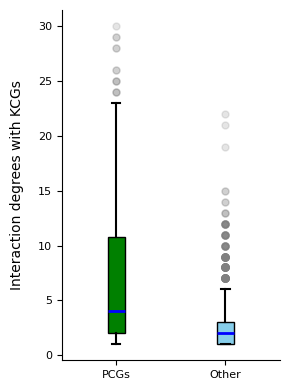

Box plot saved to results/gene_prediction/ggnet_ATTAG_degree_distributions_threshold0.85_epo100_32x4.png
Preparing data for KDE plot...
Generating KDE plot...
KDE plot saved to results/gene_prediction/ggnet_ATTAG_kde_plot_threshold0.85_epo100_32x4.png


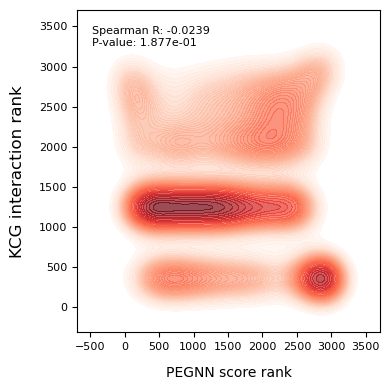

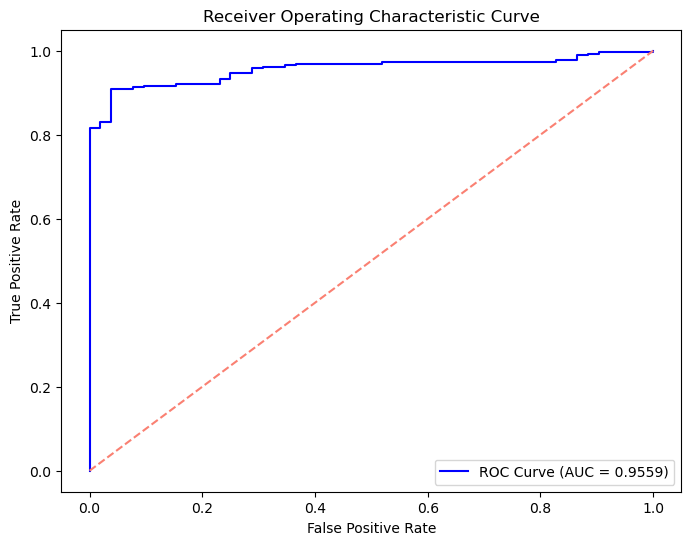

ROC Curve saved to results/gene_prediction/ggnet_ATTAG_threshold0.85_epo100_32x4_roc_curves.png


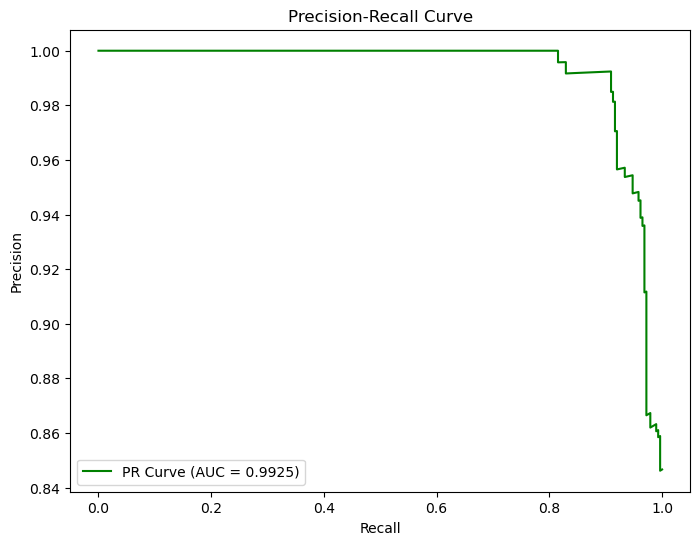

Precision-Recall Curve saved to results/gene_prediction/ggnet_ATTAG_threshold0.85_epo100_32x4_pr_curves.png


In [9]:
main(args)
